# SlowFast Baseline for Pig Behavior Recognition

This notebook documents the complete SlowFast workflow used as an RGB video baseline for pig behavior classification. The pipeline starts by converting CVAT/DeGCN-aligned annotations into individual RGB clips, aligns those clips with the same temporal folds used in the skeleton-based experiments, defines a PyTorch dataset compatible with the SlowFast two-pathway architecture, trains and evaluates SlowFast models under six-class and four-class formulations, and consolidates metrics, confusion matrices, and inference-time measurements.

The notebook is organized to support reproducibility. Each code cell is preceded by a Markdown explanation describing its purpose, expected inputs, generated outputs, and its role in the broader experimental pipeline. File paths are kept as originally used in the experiment and may need to be adapted when running the notebook on another machine.


## Step 1 — Build individual RGB clips aligned with the DeGCN reference metadata

This cell converts the original CVAT skeleton annotations into cropped RGB clips centered on each pig instance. It reads the final CVAT XML annotation file and the DeGCN metadata for the T=15 setting, extracts the corresponding frame sequences, estimates bounding boxes from the annotated keypoints, applies a margin around each animal, and saves fixed-size RGB crops. The resulting `slowfast_dataset.csv` becomes the main index file for the SlowFast visual baseline, preserving the same sample identity, temporal window definition, track identifier, and label alignment used by the skeleton-based models.


In [9]:
# =========================================================
# ETAPA 1 CORRIGIDA — GERAR CLIPS RGB POR INDIVÍDUO
# usando o XML ORIGINAL do DeGCN
# =========================================================

from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import cv2
import json

# =========================================================
# CONFIG
# =========================================================

XML_PATH = Path(r"F:\clips_3s\selection\interacao_agressiva\annotations\dataset_videos_suinos_5300.xml")
FRAMES_DIR = Path(r"F:\clips_3s\selection\interacao_agressiva\video_dataset_frames")

ROOT_DEGCN = Path(r"F:\meus_dados_degcn_5300f_T15")
META_VALID = ROOT_DEGCN / "meta_valid.csv"
LABELS_VALID = ROOT_DEGCN / "labels_valid.npy"
LABELS_MAP = ROOT_DEGCN / "labels_mix_map.json"

OUT_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
OUT_CLIPS = OUT_ROOT / "clips"
OUT_CSV = OUT_ROOT / "slowfast_dataset.csv"

T = 15
IMG_EXT = ".jpg"
FRAME_TEMPLATE = "frame_{:06d}" + IMG_EXT

# crop
MARGIN_RATIO = 0.10
OUT_W = 224
OUT_H = 224

PIG_LABELS = {"pig", "pig2"}

# debug
MAX_SAMPLES = None   # use 100 para teste rápido, ou None para tudo

# =========================================================
# HELPERS
# =========================================================

def parse_point(pt_elem):
    if pt_elem.attrib.get("outside", "0") == "1":
        return None
    pts_str = pt_elem.attrib.get("points", "").strip()
    if not pts_str:
        return None
    try:
        x, y = map(float, pts_str.split(","))
        return (x, y)
    except Exception:
        return None

def skeleton_points(sk_elem):
    pts = []
    for pt in sk_elem.findall("./points"):
        p = parse_point(pt)
        if p is not None:
            pts.append(p)
    return pts

def skeleton_bbox(sk_elem, img_w, img_h, margin_ratio=0.10):
    pts = skeleton_points(sk_elem)
    if len(pts) == 0:
        return None

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)

    bw = x2 - x1
    bh = y2 - y1

    mx = max(10, bw * margin_ratio)
    my = max(10, bh * margin_ratio)

    x1 = max(0, int(np.floor(x1 - mx)))
    y1 = max(0, int(np.floor(y1 - my)))
    x2 = min(img_w - 1, int(np.ceil(x2 + mx)))
    y2 = min(img_h - 1, int(np.ceil(y2 + my)))

    if x2 <= x1 or y2 <= y1:
        return None

    return (x1, y1, x2, y2)

def clip_name_from_meta(row):
    return f"clip_{int(row['clip_idx']):03d}_track_{int(row['track_id']):04d}_start_{int(row['start_frame']):06d}"

def load_class_names(labels_map_path):
    with open(labels_map_path, "r", encoding="utf-8") as f:
        mp = json.load(f)

    if "idx_to_class" in mp:
        idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
    elif "class_to_idx" in mp:
        idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
    else:
        idx_to_class = {int(k): v for k, v in mp.items()}

    return idx_to_class

# =========================================================
# CHECAGENS
# =========================================================

for p in [XML_PATH, FRAMES_DIR, META_VALID, LABELS_VALID, LABELS_MAP]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

OUT_CLIPS.mkdir(parents=True, exist_ok=True)
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD META / LABELS
# =========================================================

meta = pd.read_csv(META_VALID)
y = np.load(LABELS_VALID)
idx_to_class = load_class_names(LABELS_MAP)

if len(meta) != len(y):
    raise ValueError(f"meta_valid ({len(meta)}) e labels_valid ({len(y)}) têm tamanhos diferentes")

meta = meta.copy()
meta["label_idx"] = y.astype(int)
meta["label_name"] = meta["label_idx"].map(idx_to_class)

if MAX_SAMPLES is not None:
    meta = meta.iloc[:MAX_SAMPLES].copy()

print("meta_valid usado:", meta.shape)
print("Classes:", idx_to_class)

# =========================================================
# INDEXAR XML POR (track_id, frame)
# =========================================================

tree = ET.parse(XML_PATH)
root = tree.getroot()

sk_index = {}  # (track_id, frame) -> skeleton
tracks_available = set()
frames_available = set()

for tr in root.findall("./track"):
    label = tr.attrib.get("label", "").strip().lower()
    if label not in PIG_LABELS:
        continue

    tid = tr.attrib.get("id")
    if tid is None:
        continue
    tid = int(tid)
    tracks_available.add(tid)

    for sk in tr.findall("./skeleton"):
        if sk.attrib.get("outside", "0") == "1":
            continue
        frame = sk.attrib.get("frame")
        if frame is None:
            continue
        frame = int(frame)
        frames_available.add(frame)
        sk_index[(tid, frame)] = sk

print("Skeletons indexados:", len(sk_index))
print("Tracks no XML:", len(tracks_available))
print("Faixa de frames:", min(frames_available), "até", max(frames_available))

# =========================================================
# AUDITORIA RÁPIDA DE COBERTURA
# =========================================================

total_expected = 0
total_found = 0
complete_windows = 0

for _, row in meta.iterrows():
    track_id = int(row["track_id"])
    start_frame = int(row["start_frame"])

    found = 0
    for t in range(T):
        frame_idx = start_frame + t
        total_expected += 1
        if (track_id, frame_idx) in sk_index:
            found += 1
            total_found += 1

    if found == T:
        complete_windows += 1

print("\nCobertura global:", total_found / total_expected if total_expected else 0)
print("Janelas completas esperadas:", complete_windows)

# =========================================================
# GERAR CLIPS
# =========================================================

rows = []
n_ok = 0
n_missing_sk = 0
n_missing_img = 0
n_bad_bbox = 0

for _, row in meta.iterrows():
    track_id = int(row["track_id"])
    start_frame = int(row["start_frame"])
    clip_idx = int(row["clip_idx"])
    label_idx = int(row["label_idx"])
    label_name = row["label_name"]

    clip_name = clip_name_from_meta(row)
    clip_dir = OUT_CLIPS / clip_name
    clip_dir.mkdir(parents=True, exist_ok=True)

    frames_written = 0

    for t in range(T):
        frame_idx = start_frame + t
        img_path = FRAMES_DIR / FRAME_TEMPLATE.format(frame_idx)

        if not img_path.exists():
            n_missing_img += 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            n_missing_img += 1
            continue

        h, w = img.shape[:2]

        sk = sk_index.get((track_id, frame_idx), None)
        if sk is None:
            n_missing_sk += 1
            continue

        box = skeleton_bbox(sk, w, h, margin_ratio=MARGIN_RATIO)
        if box is None:
            n_bad_bbox += 1
            continue

        x1, y1, x2, y2 = box
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            n_bad_bbox += 1
            continue

        crop = cv2.resize(crop, (OUT_W, OUT_H), interpolation=cv2.INTER_LINEAR)

        out_frame = clip_dir / f"img_{t:03d}.jpg"
        cv2.imwrite(str(out_frame), crop)
        frames_written += 1

    if frames_written == T:
        rows.append({
            "clip_name": clip_name,
            "clip_dir": str(clip_dir),
            "clip_idx": clip_idx,
            "track_id": track_id,
            "start_frame": start_frame,
            "label_idx": label_idx,
            "label_name": label_name,
            "n_frames": frames_written
        })
        n_ok += 1
    else:
        for p in clip_dir.glob("*.jpg"):
            p.unlink()
        try:
            clip_dir.rmdir()
        except Exception:
            pass

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("\n[OK] CSV salvo em:", OUT_CSV)
print("Clips completos gerados:", n_ok)
print("Skeleton ausente:", n_missing_sk)
print("Imagem ausente :", n_missing_img)
print("BBox ruim      :", n_bad_bbox)
print("df.shape       :", df.shape)

display(df.head())
print("\nDistribuição por classe:")
display(df["label_name"].value_counts())

meta_valid usado: (2809, 8)
Classes: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}
Skeletons indexados: 62651
Tracks no XML: 390
Faixa de frames: 0 até 5299

Cobertura global: 1.0
Janelas completas esperadas: 2809

[OK] CSV salvo em: F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_dataset.csv
Clips completos gerados: 2808
Skeleton ausente: 0
Imagem ausente : 0
BBox ruim      : 1
df.shape       : (2808, 8)


,clip_name,clip_dir,clip_idx,track_id,start_frame,label_idx,label_name,n_frames
0,clip_010_track_0000_start_000150,F:\slowfast_dataset_degcn_aligned_5300xml\clip...,10,0,150,5,sleeping,15
1,clip_013_track_0000_start_000195,F:\slowfast_dataset_degcn_aligned_5300xml\clip...,13,0,195,0,walking,15
2,clip_014_track_0000_start_000210,F:\slowfast_dataset_degcn_aligned_5300xml\clip...,14,0,210,0,walking,15
3,clip_015_track_0000_start_000225,F:\slowfast_dataset_degcn_aligned_5300xml\clip...,15,0,225,3,drinking,15
4,clip_016_track_0000_start_000240,F:\slowfast_dataset_degcn_aligned_5300xml\clip...,16,0,240,3,drinking,15



Distribuição por classe:


label_name
sleeping       777
eating         652
lying awake    585
walking        395
running        223
drinking       176
Name: count, dtype: int64

## Empty cell

This cell is empty in the original notebook and is kept only to preserve the original cell ordering.


## Step 2 — Align the SlowFast dataset with `meta_valid.csv` and recreate temporal folds

This cell aligns the generated RGB clip dataset with the DeGCN metadata (`meta_valid.csv`) and label array. This alignment is essential because the visual baseline must use exactly the same samples and temporal train/validation splits as the skeleton-based models. The cell normalizes key columns, merges metadata by clip and track identifiers, verifies consistency, and exports fold-specific CSV and index files under `folds_aligned/`.


In [17]:
# =========================================================
# ETAPA 2 CORRIGIDA — ALINHAR SLOWFAST COM meta_valid
# e recriar folds sem erro de nomes de colunas
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

ROOT_SF = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
CSV_SF = ROOT_SF / "slowfast_dataset.csv"
OUTDIR = ROOT_SF / "folds_aligned"
OUTDIR.mkdir(parents=True, exist_ok=True)

ROOT_DEGCN = Path(r"F:\meus_dados_degcn_5300f_T15")
META_VALID = ROOT_DEGCN / "meta_valid.csv"
LABELS_VALID = ROOT_DEGCN / "labels_valid.npy"
SPLITS = ROOT_DEGCN / "splits_temporal_5fold_blocks"
LABELS_MAP = ROOT_DEGCN / "labels_mix_map.json"

for p in [CSV_SF, META_VALID, LABELS_VALID, LABELS_MAP]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------

df_sf = pd.read_csv(CSV_SF)
meta = pd.read_csv(META_VALID)
y = np.load(LABELS_VALID)

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

meta = meta.copy()
meta["label_idx"] = y.astype(int)
meta["label_name"] = meta["label_idx"].map(idx_to_class)
meta["orig_idx"] = np.arange(len(meta))

# normalizar tipos
key_cols = ["clip_idx", "track_id", "start_frame"]
for c in key_cols:
    df_sf[c] = df_sf[c].astype(int)
    meta[c] = meta[c].astype(int)

# ---------------------------------------------------------
# ALIGN
# ---------------------------------------------------------

merged = meta.merge(
    df_sf,
    on=key_cols,
    how="left",
    suffixes=("_meta", "_sf"),
    indicator=True
)

print("meta_valid.shape :", meta.shape)
print("slowfast_dataset.shape :", df_sf.shape)
print("merged.shape :", merged.shape)

print("\nColunas do merged:")
print(list(merged.columns))

missing = merged[merged["_merge"] != "both"].copy()
print("\nAmostras do meta_valid sem clip SlowFast correspondente:", len(missing))

if len(missing) > 0:
    print("\nExemplo(s) faltante(s):")
    display(missing.head(10)[["orig_idx", "clip_idx", "track_id", "start_frame", "label_idx_meta", "label_name_meta"]])

# manter só alinhadas
aligned = merged[merged["_merge"] == "both"].copy().reset_index(drop=True)

# detectar nomes corretos das colunas do lado slowfast
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Nenhuma das colunas {candidates} encontrada.")

clip_name_col = pick_col(aligned, ["clip_name_sf", "clip_name"])
clip_dir_col  = pick_col(aligned, ["clip_dir_sf", "clip_dir"])
n_frames_col  = pick_col(aligned, ["n_frames_sf", "n_frames"])
label_idx_col = pick_col(aligned, ["label_idx_meta", "label_idx"])
label_name_col = pick_col(aligned, ["label_name_meta", "label_name"])

aligned_final = aligned[[
    "orig_idx",
    clip_name_col,
    clip_dir_col,
    "clip_idx",
    "track_id",
    "start_frame",
    label_idx_col,
    label_name_col,
    n_frames_col
]].copy()

aligned_final.columns = [
    "orig_idx",
    "clip_name",
    "clip_dir",
    "clip_idx",
    "track_id",
    "start_frame",
    "label_idx",
    "label_name",
    "n_frames"
]

print("\nDataset SlowFast alinhado:", aligned_final.shape)

# salvar versão alinhada
aligned_csv = ROOT_SF / "slowfast_dataset_aligned.csv"
aligned_final.to_csv(aligned_csv, index=False, encoding="utf-8-sig")
print("[OK] CSV alinhado salvo em:", aligned_csv)

# mapa do índice original do DeGCN -> novo índice do SlowFast alinhado
orig_to_new = {int(orig_idx): i for i, orig_idx in enumerate(aligned_final["orig_idx"].tolist())}

# ---------------------------------------------------------
# RECRIAR FOLDS
# ---------------------------------------------------------

summary = []

for fold in range(5):
    tr_idx_orig = np.load(SPLITS / f"fold{fold}_train_idx.npy")
    va_idx_orig = np.load(SPLITS / f"fold{fold}_val_idx.npy")

    tr_idx_new = np.array([orig_to_new[i] for i in tr_idx_orig if int(i) in orig_to_new], dtype=np.int64)
    va_idx_new = np.array([orig_to_new[i] for i in va_idx_orig if int(i) in orig_to_new], dtype=np.int64)

    df_tr = aligned_final.iloc[tr_idx_new].reset_index(drop=True)
    df_va = aligned_final.iloc[va_idx_new].reset_index(drop=True)

    df_tr.to_csv(OUTDIR / f"fold{fold}_train.csv", index=False, encoding="utf-8-sig")
    df_va.to_csv(OUTDIR / f"fold{fold}_val.csv", index=False, encoding="utf-8-sig")

    np.save(OUTDIR / f"fold{fold}_train_idx.npy", tr_idx_new)
    np.save(OUTDIR / f"fold{fold}_val_idx.npy", va_idx_new)

    summary.append({
        "fold": fold,
        "n_train": len(df_tr),
        "n_val": len(df_va),
        "lost_train_samples": len(tr_idx_orig) - len(tr_idx_new),
        "lost_val_samples": len(va_idx_orig) - len(va_idx_new),
    })

    print(f"\nFold {fold}")
    print("train:", df_tr.shape)
    print("val  :", df_va.shape)
    print("classes val:")
    print(df_va["label_name"].value_counts())

summary_df = pd.DataFrame(summary)
print("\nResumo dos folds:")
display(summary_df)

print("\n[OK] Folds alinhados salvos em:", OUTDIR)

meta_valid.shape : (2809, 9)
slowfast_dataset.shape : (2808, 8)
merged.shape : (2809, 15)

Colunas do merged:
['video_id', 'track_id', 'start_frame', 'clip_idx', 'clip_name_meta', 'clip_path', 'label_idx_meta', 'label_name_meta', 'orig_idx', 'clip_name_sf', 'clip_dir', 'label_idx_sf', 'label_name_sf', 'n_frames', '_merge']

Amostras do meta_valid sem clip SlowFast correspondente: 1

Exemplo(s) faltante(s):


,orig_idx,clip_idx,track_id,start_frame,label_idx_meta,label_name_meta
2533,2533,352,389,5280,1,running



Dataset SlowFast alinhado: (2808, 9)
[OK] CSV alinhado salvo em: F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_dataset_aligned.csv

Fold 0
train: (2430, 9)
val  : (378, 9)
classes val:
label_name
lying awake    109
sleeping       107
walking         81
eating          73
drinking         6
running          2
Name: count, dtype: int64

Fold 1
train: (2318, 9)
val  : (490, 9)
classes val:
label_name
sleeping       180
eating         154
lying awake    114
walking         29
drinking        11
running          2
Name: count, dtype: int64

Fold 2
train: (2220, 9)
val  : (588, 9)
classes val:
label_name
sleeping       236
lying awake    148
eating         115
drinking        68
walking         21
Name: count, dtype: int64

Fold 3
train: (2070, 9)
val  : (738, 9)
classes val:
label_name
eating         266
sleeping       247
lying awake    117
drinking        81
walking         25
running          2
Name: count, dtype: int64

Fold 4
train: (2194, 9)
val  : (614, 9)
classes val:
label_na

,fold,n_train,n_val,lost_train_samples,lost_val_samples
0,0,2430,378,1,0
1,1,2318,490,1,0
2,2,2220,588,1,0
3,3,2070,738,1,0
4,4,2194,614,0,1



[OK] Folds alinhados salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\folds_aligned


## Environment check for PyTorch, CUDA, and PyTorchVideo

This cell verifies whether the computational environment is ready to run SlowFast. It reports the installed PyTorch version, checks CUDA availability, displays the GPU name when available, and attempts to import the `slowfast_r50` model from PyTorchVideo. This is an early diagnostic step to avoid running the training cells before the required dependencies are correctly installed.


In [19]:
# =========================================================
# TESTE DO AMBIENTE SLOWFAST
# =========================================================

import torch

print("Torch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

try:
    from pytorchvideo.models.hub import slowfast_r50
    print("PyTorchVideo OK")
except Exception as e:
    print("PyTorchVideo NÃO disponível")
    print(type(e).__name__, ":", e)

Torch: 2.5.1
CUDA disponível: True
GPU: NVIDIA GeForce RTX 3070
PyTorchVideo NÃO disponível
ModuleNotFoundError : No module named 'pytorchvideo'


## Install PyTorchVideo

This cell installs the `pytorchvideo` package. It is intended for environments where PyTorchVideo is not already available. If the package is already installed, this cell can be skipped.


In [21]:
pip install pytorchvideo

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/29.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/29.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/29.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/29.0 MB ? eta -:--:--
    --------------------------------------- 0.5/29.0 MB 670.4 kB/s eta 0:00:43
    --------------------------------------- 0.5/29.0 MB 670.4 kB/s eta 0:00:43
   - -------------------------------------- 0.8/29.0 MB 762.0 kB/s eta 0:00:38
   - -------------------------------------- 1.0/29.0 MB 825.2 kB/s eta 0:00:34
   - -------------------------------------- 1.0/29.0 MB 825.2 kB/s eta 0:00:34
   - --------------

  DEPRECATION: Building 'pytorchvideo' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pytorchvideo'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'fvcore'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'iopath' using the legacy setup.py bdist_wheel mecha

## Verify the SlowFast model import

This cell performs a minimal import test for `slowfast_r50` from PyTorchVideo. A successful import confirms that the SlowFast model factory is available for later training and evaluation cells.


In [23]:
from pytorchvideo.models.hub import slowfast_r50
print("OK")

OK


## Install auxiliary video-model dependencies

This cell installs auxiliary packages commonly required by PyTorchVideo, including `av`, `iopath`, and `fvcore`, and then installs PyTorchVideo directly from the official GitHub repository. It is useful when the standard package installation does not provide all components required by the local environment.


In [31]:
!pip install av iopath fvcore
!pip install "git+https://github.com/facebookresearch/pytorchvideo.git"

  Using cached iopath-0.1.10.tar.gz (42 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
   ---------------------------------------- 0.0/28.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/28.9 MB 7.4 MB/s eta 0:00:04
   -- ------------------------------------- 1.8/28.9 MB 5.6 MB/s eta 0:00:05
   -- ------------------------------------- 2.1/28.9 MB 3.6 MB/s eta 0:00:08
   -- ------------------------------------- 2.1/28.9 MB 3.6 MB/s eta 0:00:08
   --- ------------------------------------ 2.4/28.9 MB 2.6 MB/s eta 0:00:11
   --- ------------------------------------ 2.4/28.9 MB 2.6 MB/s eta 0:00:11
   --- -------------------------

  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/pytorchvideo.git 'C:\Users\pedro\AppData\Local\Temp\pip-req-build-styh6cfo'


## Define the `PigSlowFastDataset` class

This cell defines the custom PyTorch dataset used by the SlowFast experiments. For each sample, it reads the 15-frame RGB clip from disk, resizes and normalizes each frame, converts images from HWC to CHW format, and constructs the two SlowFast pathways: a fast pathway with denser temporal sampling and a slow pathway with fewer temporal samples. It also returns metadata fields so predictions can later be traced back to the original clip, track, and temporal window.


In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            if not p.exists():
                raise FileNotFoundError(f"Frame ausente: {p}")

            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Não foi possível ler {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if img.shape[:2] != (self.img_size, self.img_size):
                img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
            frames.append(img)

        # src_T x C x H x W
        clip = np.stack(frames, axis=0)
        return clip

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        src_clip = self._load_src_clip(row["clip_dir"])  # (15, C, H, W)

        # fast pathway: 15 -> 32
        fast = src_clip[self.fast_idx]                   # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))         # (C, 32, H, W)

        # slow pathway: 32 -> 8
        slow = fast[:, self.slow_idx, :, :]             # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)

        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }

        return [slow, fast], y, meta

## Define the custom batch collation function

This cell defines `collate_fn`, which assembles individual dataset samples into the input format expected by PyTorchVideo SlowFast models. The function stacks slow-pathway tensors, fast-pathway tensors, labels, and metadata, returning the visual inputs as a list `[slow, fast]` along with the target labels and sample metadata.


In [39]:
def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

## Sanity check for one dataset sample and one mini-batch

This cell validates the dataset and data loader before model training. It loads the first sample from fold 0, prints the tensor shapes for the slow and fast pathways, checks the label and metadata, and then constructs a small mini-batch. The expected shapes confirm that the data are compatible with the SlowFast architecture.


In [41]:
from pathlib import Path
from torch.utils.data import DataLoader

CSV_FOLD0_TRAIN = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\folds_aligned\fold0_train.csv")

ds = PigSlowFastDataset(CSV_FOLD0_TRAIN, src_frames=15, fast_frames=32, slow_frames=8, img_size=224)
print("len(ds) =", len(ds))

x, y, meta = ds[0]
print("slow shape:", x[0].shape)   # esperado: [3, 8, 224, 224]
print("fast shape:", x[1].shape)   # esperado: [3, 32, 224, 224]
print("label:", y)
print("meta:", meta)

loader = DataLoader(ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
xb, yb, mb = next(iter(loader))

print("batch slow:", xb[0].shape)  # esperado: [2, 3, 8, 224, 224]
print("batch fast:", xb[1].shape)  # esperado: [2, 3, 32, 224, 224]
print("batch y:", yb.shape)

len(ds) = 2430
slow shape: torch.Size([3, 8, 224, 224])
fast shape: torch.Size([3, 32, 224, 224])
label: 5
meta: {'clip_name': 'clip_070_track_0000_start_001050', 'clip_idx': 70, 'track_id': 0, 'start_frame': 1050, 'label_name': 'sleeping'}
batch slow: torch.Size([2, 3, 8, 224, 224])
batch fast: torch.Size([2, 3, 32, 224, 224])
batch y: torch.Size([2])


## Additional dataset and DataLoader validation

This cell performs another lightweight validation of the `PigSlowFastDataset` and `DataLoader` using the aligned training CSV. It confirms that the dataset can be iterated, checks the output shapes for both pathways, and prints an example metadata record. This helps detect missing clip files or formatting problems before training.


In [5]:
# =========================================================
# DATASET SLOWFAST (DEFINIÇÃO)
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"

            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))

            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
            frames.append(img)

        clip = np.stack(frames, axis=0)  # (15, C, H, W)
        return clip

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        src_clip = self._load_src_clip(row["clip_dir"])  # (15, C, H, W)

        fast = src_clip[self.fast_idx]                   # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))         # (C, 32, H, W)

        slow = fast[:, self.slow_idx, :, :]             # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)

        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }

        return [slow, fast], y, meta


# =========================================================
# COLLATE FUNCTION
# =========================================================

def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

print("✅ Dataset carregado")

✅ Dataset carregado


## Train and evaluate a one-fold SlowFast prototype

This cell trains a preliminary SlowFast model on fold 0 using the aligned RGB clip dataset. It loads the class mapping, replaces the final classification head to match the number of behavior classes, runs a short training configuration, evaluates on the validation fold, and stores the predicted labels and true labels for later reporting. This prototype cell is useful for debugging the full training pipeline before running all five folds.


In [7]:
from pathlib import Path
from torch.utils.data import DataLoader

CSV_TRAIN = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\folds_aligned\fold0_train.csv")

ds_train = PigSlowFastDataset(CSV_TRAIN, 15, 32, 8, 224)
print("len(ds_train) =", len(ds_train))

dl_train = DataLoader(ds_train, batch_size=2, shuffle=True, num_workers=0, collate_fn=collate_fn)

xb, yb, mb = next(iter(dl_train))
print("slow:", xb[0].shape)
print("fast:", xb[1].shape)
print("y   :", yb.shape)
print("meta exemplo:", mb[0])

len(ds_train) = 2430
slow: torch.Size([2, 3, 8, 224, 224])
fast: torch.Size([2, 3, 32, 224, 224])
y   : torch.Size([2])
meta exemplo: {'clip_name': 'clip_190_track_0293_start_002850', 'clip_idx': 190, 'track_id': 293, 'start_frame': 2850, 'label_name': 'lying awake'}


## Generate the fold-0 classification report and confusion matrix

This cell summarizes the predictions produced by the previous training cell. It computes a classification report with precision, recall, F1-score, and support for each class, and builds a confusion matrix indexed by the behavior names. This provides an immediate diagnostic view of per-class performance on fold 0.


In [9]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
from pytorchvideo.models.hub import slowfast_r50

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
FOLDS = ROOT / "folds_aligned"
CSV_TRAIN = FOLDS / "fold0_train.csv"
CSV_VAL   = FOLDS / "fold0_val.csv"
LABELS_MAP = Path(r"F:\meus_dados_degcn_5300f_T15\labels_mix_map.json")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2
NUM_WORKERS = 0
EPOCHS = 1
LR = 1e-4

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

NUM_CLASSES = len(idx_to_class)

print("Criando datasets...")
ds_train = PigSlowFastDataset(CSV_TRAIN, 15, 32, 8, 224)
ds_val   = PigSlowFastDataset(CSV_VAL,   15, 32, 8, 224)
print("Train:", len(ds_train), "Val:", len(ds_val))

print("Testando loader...")
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

xb, yb, mb = next(iter(dl_train))
print("batch slow:", xb[0].shape)
print("batch fast:", xb[1].shape)
print("batch y   :", yb.shape)

print("Criando modelo...")
model = slowfast_r50(pretrained=False)
in_features = model.blocks[-1].proj.in_features
model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Iniciando 1 época...")
for epoch in range(EPOCHS):
    model.train()
    losses = []

    for i, (x, y, _) in enumerate(dl_train):
        if i % 20 == 0:
            print(f"[TRAIN] batch {i}/{len(dl_train)}")

        x = [t.to(DEVICE) for t in x]
        y = y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print("Loss médio:", float(np.mean(losses)))

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for i, (x, y, _) in enumerate(dl_val):
            if i % 20 == 0:
                print(f"[VAL] batch {i}/{len(dl_val)}")

            x = [t.to(DEVICE) for t in x]
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_true.append(y.numpy())
            y_pred.append(pred)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print("Val acc:", accuracy_score(y_true, y_pred))
    print("Val macro-F1:", f1_score(y_true, y_pred, average="macro"))

print("Fim do teste.")

Criando datasets...
Train: 2430 Val: 378
Testando loader...
batch slow: torch.Size([2, 3, 8, 224, 224])
batch fast: torch.Size([2, 3, 32, 224, 224])
batch y   : torch.Size([2])
Criando modelo...
Iniciando 1 época...
[TRAIN] batch 0/1215
[TRAIN] batch 20/1215
[TRAIN] batch 40/1215
[TRAIN] batch 60/1215
[TRAIN] batch 80/1215
[TRAIN] batch 100/1215
[TRAIN] batch 120/1215
[TRAIN] batch 140/1215
[TRAIN] batch 160/1215
[TRAIN] batch 180/1215
[TRAIN] batch 200/1215
[TRAIN] batch 220/1215
[TRAIN] batch 240/1215
[TRAIN] batch 260/1215
[TRAIN] batch 280/1215
[TRAIN] batch 300/1215
[TRAIN] batch 320/1215
[TRAIN] batch 340/1215
[TRAIN] batch 360/1215
[TRAIN] batch 380/1215
[TRAIN] batch 400/1215
[TRAIN] batch 420/1215
[TRAIN] batch 440/1215
[TRAIN] batch 460/1215
[TRAIN] batch 480/1215
[TRAIN] batch 500/1215
[TRAIN] batch 520/1215
[TRAIN] batch 540/1215
[TRAIN] batch 560/1215
[TRAIN] batch 580/1215
[TRAIN] batch 600/1215
[TRAIN] batch 620/1215
[TRAIN] batch 640/1215
[TRAIN] batch 660/1215
[TRAIN] 

## Train SlowFast across five temporal folds for the six-class setting

This cell runs the full five-fold SlowFast training pipeline for the six-class behavioral formulation. For each fold, it loads the aligned train/validation CSV files, initializes a SlowFast R50 model, replaces the classification head, trains for the configured number of epochs, evaluates the validation fold, and saves fold-level artifacts such as predictions, probabilities, metrics, confusion matrices, class names, and training history. These artifacts are later consolidated for final reporting.


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# y_true e y_pred devem existir da célula anterior
print("=== Classification report - Fold 0 ===")
rep = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=[idx_to_class[i] for i in sorted(idx_to_class)],
    digits=4,
    zero_division=0
)
print(rep)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
cm_df = pd.DataFrame(
    cm,
    index=[idx_to_class[i] for i in sorted(idx_to_class)],
    columns=[idx_to_class[i] for i in sorted(idx_to_class)]
)

print("\n=== Matriz de confusão - Fold 0 ===")
display(cm_df)

=== Classification report - Fold 0 ===
              precision    recall  f1-score   support

     walking     0.8250    0.4074    0.5455        81
     running     0.0000    0.0000    0.0000         2
      eating     0.3167    0.9589    0.4762        73
    drinking     0.2500    0.6667    0.3636         6
 lying awake     0.4286    0.0275    0.0517       109
    sleeping     0.5319    0.4673    0.4975       107

    accuracy                         0.4233       378
   macro avg     0.3920    0.4213    0.3224       378
weighted avg     0.5161    0.4233    0.3704       378


=== Matriz de confusão - Fold 0 ===


,walking,running,eating,drinking,lying awake,sleeping
walking,33,0,34,7,4,3
running,2,0,0,0,0,0
eating,0,0,70,0,0,3
drinking,0,0,0,4,0,2
lying awake,5,0,61,4,3,36
sleeping,0,0,56,1,0,50


## Consolidate SlowFast six-class metrics across all folds

This cell aggregates validation predictions from the five SlowFast folds. It concatenates fold-level outputs, computes global accuracy, macro-F1, weighted-F1, average precision scores, a full classification report, and raw/normalized confusion matrices. It also saves publication-ready metric tables and figures under the consolidated metrics directory.


In [13]:
# =========================================================
# TREINO SLOWFAST — 5 FOLDS
# salva artefatos por fold para consolidação posterior
# =========================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from pytorchvideo.models.hub import slowfast_r50

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
FOLDS_DIR = ROOT / "folds_aligned"
SAVE_ROOT = ROOT / "slowfast_runs_5fold"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

LABELS_MAP = Path(r"F:\meus_dados_degcn_5300f_T15\labels_mix_map.json")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
NUM_WORKERS = 0   # Windows
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 224
SRC_FRAMES = 15
FAST_FRAMES = 32
SLOW_FRAMES = 8

print("DEVICE:", DEVICE)

# ---------------------------------------------------------
# CLASSES
# ---------------------------------------------------------

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

# salvar nomes das classes junto dos resultados
with open(SAVE_ROOT / "class_names.json", "w", encoding="utf-8") as f:
    json.dump({"idx_to_class": {str(i): c for i, c in enumerate(class_names)}}, f, ensure_ascii=False, indent=2)

# ---------------------------------------------------------
# LOOP POR FOLD
# ---------------------------------------------------------

global_summary = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    csv_train = FOLDS_DIR / f"fold{fold}_train.csv"
    csv_val   = FOLDS_DIR / f"fold{fold}_val.csv"

    if not csv_train.exists() or not csv_val.exists():
        raise FileNotFoundError(f"CSV do fold {fold} não encontrado.")

    fold_dir = SAVE_ROOT / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    # -----------------------------------------------------
    # DATASETS / LOADERS
    # -----------------------------------------------------

    ds_train = PigSlowFastDataset(csv_train, SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)
    ds_val   = PigSlowFastDataset(csv_val,   SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)

    dl_train = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_fn
    )

    dl_val = DataLoader(
        ds_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_fn
    )

    print("Train:", len(ds_train))
    print("Val  :", len(ds_val))

    # -----------------------------------------------------
    # CLASS WEIGHTS
    # -----------------------------------------------------

    df_train = pd.read_csv(csv_train)
    counts = df_train["label_idx"].value_counts().sort_index()

    weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for c in range(NUM_CLASSES):
        n = counts.get(c, 1)
        weights[c] = len(df_train) / (NUM_CLASSES * n)

    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print("Class weights:", weights)

    # -----------------------------------------------------
    # MODEL
    # -----------------------------------------------------

    model = slowfast_r50(pretrained=False)
    in_features = model.blocks[-1].proj.in_features
    model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2, verbose=True
    )

    best_macro_f1 = -1.0
    best_epoch = -1
    history = []

    # -----------------------------------------------------
    # EPOCHS
    # -----------------------------------------------------

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n[FOLD {fold}] EPOCH {epoch+1}/{EPOCHS}")

        # ---------------- TRAIN ----------------
        model.train()
        train_losses = []

        for i, (x, y, _) in enumerate(dl_train):
            if i % 50 == 0:
                print(f"[TRAIN] batch {i}/{len(dl_train)}")

            x = [t.to(DEVICE, non_blocking=True) for t in x]
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan

        # ---------------- VAL ----------------
        model.eval()
        y_true = []
        y_pred = []
        probs_all = []
        meta_all = []

        with torch.no_grad():
            for i, (x, y, meta_batch) in enumerate(dl_val):
                if i % 50 == 0:
                    print(f"[VAL] batch {i}/{len(dl_val)}")

                x = [t.to(DEVICE, non_blocking=True) for t in x]

                logits = model(x)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = probs.argmax(axis=1)

                y_true.append(y.numpy())
                y_pred.append(pred)
                probs_all.append(probs)
                meta_all.extend(meta_batch)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        probs_all = np.concatenate(probs_all)

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")

        epoch_time = time.time() - t0

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_acc": acc,
            "val_macro_f1": macro_f1,
            "val_weighted_f1": weighted_f1,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[FOLD {fold}] epoch={epoch+1} | "
            f"loss={train_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"macro_f1={macro_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        scheduler.step(macro_f1)

        # ---------------- SAVE BEST ----------------
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1

            print(f"🔥 [FOLD {fold}] Novo melhor modelo na época {best_epoch} (macro-F1={best_macro_f1:.4f})")

            torch.save(model.state_dict(), fold_dir / "best.pt")

            np.savez_compressed(
                fold_dir / "val_artifacts_best.npz",
                y_true=y_true,
                y_pred=y_pred,
                probs=probs_all
            )

            pd.DataFrame(meta_all).to_csv(
                fold_dir / "meta_val_best.csv",
                index=False,
                encoding="utf-8-sig"
            )

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
            cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
            cm_df.to_csv(
                fold_dir / "confusion_matrix_best.csv",
                encoding="utf-8-sig"
            )

            rep = classification_report(
                y_true,
                y_pred,
                labels=np.arange(NUM_CLASSES),
                target_names=class_names,
                output_dict=True,
                zero_division=0
            )
            rep_df = pd.DataFrame(rep).T
            rep_df.to_csv(
                fold_dir / "classification_report_best.csv",
                encoding="utf-8-sig"
            )

            with open(fold_dir / "summary_best.json", "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "fold": fold,
                        "best_epoch": best_epoch,
                        "best_val_acc": acc,
                        "best_val_macro_f1": macro_f1,
                        "best_val_weighted_f1": weighted_f1,
                        "n_train": len(ds_train),
                        "n_val": len(ds_val),
                        "class_names": class_names,
                    },
                    f,
                    ensure_ascii=False,
                    indent=2
                )

        pd.DataFrame(history).to_csv(
            fold_dir / "history.csv",
            index=False,
            encoding="utf-8-sig"
        )

    # resumo por fold
    global_summary.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    })

# ---------------------------------------------------------
# SAVE GLOBAL SUMMARY
# ---------------------------------------------------------

global_summary_df = pd.DataFrame(global_summary)
global_summary_df.to_csv(
    SAVE_ROOT / "global_summary_folds.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 70)
print("[OK] TREINAMENTO 5 FOLDS FINALIZADO")
print("=" * 70)
display(global_summary_df)
print("Artefatos salvos em:", SAVE_ROOT)

DEVICE: cuda
Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']

FOLD 0
Train: 2430
Val  : 378
Class weights: tensor([1.2898, 1.8326, 0.6995, 2.3824, 0.8508, 0.6045], device='cuda:0')


C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[FOLD 0] EPOCH 1/10
[TRAIN] batch 0/1215
[TRAIN] batch 50/1215
[TRAIN] batch 100/1215
[TRAIN] batch 150/1215
[TRAIN] batch 200/1215
[TRAIN] batch 250/1215
[TRAIN] batch 300/1215
[TRAIN] batch 350/1215
[TRAIN] batch 400/1215
[TRAIN] batch 450/1215
[TRAIN] batch 500/1215
[TRAIN] batch 550/1215
[TRAIN] batch 600/1215
[TRAIN] batch 650/1215
[TRAIN] batch 700/1215
[TRAIN] batch 750/1215
[TRAIN] batch 800/1215
[TRAIN] batch 850/1215
[TRAIN] batch 900/1215
[TRAIN] batch 950/1215
[TRAIN] batch 1000/1215
[TRAIN] batch 1050/1215
[TRAIN] batch 1100/1215
[TRAIN] batch 1150/1215
[TRAIN] batch 1200/1215
[VAL] batch 0/189
[VAL] batch 50/189
[VAL] batch 100/189
[VAL] batch 150/189
[FOLD 0] epoch=1 | loss=1.3438 | acc=0.2884 | macro_f1=0.1731 | weighted_f1=0.2012 | time=282.1s
🔥 [FOLD 0] Novo melhor modelo na época 1 (macro-F1=0.1731)

[FOLD 0] EPOCH 2/10
[TRAIN] batch 0/1215
[TRAIN] batch 50/1215
[TRAIN] batch 100/1215
[TRAIN] batch 150/1215
[TRAIN] batch 200/1215
[TRAIN] batch 250/1215
[TRAIN] batch

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[FOLD 1] EPOCH 1/10
[TRAIN] batch 0/1159
[TRAIN] batch 50/1159
[TRAIN] batch 100/1159
[TRAIN] batch 150/1159
[TRAIN] batch 200/1159
[TRAIN] batch 250/1159
[TRAIN] batch 300/1159
[TRAIN] batch 350/1159
[TRAIN] batch 400/1159
[TRAIN] batch 450/1159
[TRAIN] batch 500/1159
[TRAIN] batch 550/1159
[TRAIN] batch 600/1159
[TRAIN] batch 650/1159
[TRAIN] batch 700/1159
[TRAIN] batch 750/1159
[TRAIN] batch 800/1159
[TRAIN] batch 850/1159
[TRAIN] batch 900/1159
[TRAIN] batch 950/1159
[TRAIN] batch 1000/1159
[TRAIN] batch 1050/1159
[TRAIN] batch 1100/1159
[TRAIN] batch 1150/1159
[VAL] batch 0/245
[VAL] batch 50/245
[VAL] batch 100/245
[VAL] batch 150/245
[VAL] batch 200/245
[FOLD 1] epoch=1 | loss=1.3787 | acc=0.4286 | macro_f1=0.3576 | weighted_f1=0.4465 | time=265.2s
🔥 [FOLD 1] Novo melhor modelo na época 1 (macro-F1=0.3576)

[FOLD 1] EPOCH 2/10
[TRAIN] batch 0/1159
[TRAIN] batch 50/1159
[TRAIN] batch 100/1159
[TRAIN] batch 150/1159
[TRAIN] batch 200/1159
[TRAIN] batch 250/1159
[TRAIN] batch 300

...


[FOLD 3] EPOCH 1/10
[TRAIN] batch 0/1035
[TRAIN] batch 50/1035
[TRAIN] batch 100/1035
[TRAIN] batch 150/1035
[TRAIN] batch 200/1035
[TRAIN] batch 250/1035
[TRAIN] batch 300/1035
[TRAIN] batch 350/1035
[TRAIN] batch 400/1035
[TRAIN] batch 450/1035
[TRAIN] batch 500/1035
[TRAIN] batch 550/1035
[TRAIN] batch 600/1035
[TRAIN] batch 650/1035
[TRAIN] batch 700/1035
[TRAIN] batch 750/1035
[TRAIN] batch 800/1035
[TRAIN] batch 850/1035
[TRAIN] batch 900/1035
[TRAIN] batch 950/1035
[TRAIN] batch 1000/1035
[VAL] batch 0/369
[VAL] batch 50/369
[VAL] batch 100/369
[VAL] batch 150/369
[VAL] batch 200/369
[VAL] batch 250/369
[VAL] batch 300/369
[VAL] batch 350/369
[FOLD 3] epoch=1 | loss=1.4540 | acc=0.6341 | macro_f1=0.3886 | weighted_f1=0.5784 | time=252.3s
🔥 [FOLD 3] Novo melhor modelo na época 1 (macro-F1=0.3886)

[FOLD 3] EPOCH 2/10
[TRAIN] batch 0/1035
[TRAIN] batch 50/1035
[TRAIN] batch 100/1035
[TRAIN] batch 150/1035
[TRAIN] batch 200/1035
[TRAIN] batch 250/1035
[TRAIN] batch 300/1035
[TRAIN

C:\Users\pedro\anaconda3\envs\vision_pose_cuda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



[FOLD 4] EPOCH 1/10
[TRAIN] batch 0/1097
[TRAIN] batch 50/1097
[TRAIN] batch 100/1097
[TRAIN] batch 150/1097
[TRAIN] batch 200/1097
[TRAIN] batch 250/1097
[TRAIN] batch 300/1097
[TRAIN] batch 350/1097
[TRAIN] batch 400/1097
[TRAIN] batch 450/1097
[TRAIN] batch 500/1097
[TRAIN] batch 550/1097
[TRAIN] batch 600/1097
[TRAIN] batch 650/1097
[TRAIN] batch 700/1097
[TRAIN] batch 750/1097
[TRAIN] batch 800/1097
[TRAIN] batch 850/1097
[TRAIN] batch 900/1097
[TRAIN] batch 950/1097
[TRAIN] batch 1000/1097
[TRAIN] batch 1050/1097
[VAL] batch 0/307
[VAL] batch 50/307
[VAL] batch 100/307
[VAL] batch 150/307
[VAL] batch 200/307
[VAL] batch 250/307
[VAL] batch 300/307
[FOLD 4] epoch=1 | loss=1.2919 | acc=0.4479 | macro_f1=0.3473 | weighted_f1=0.3047 | time=258.7s
🔥 [FOLD 4] Novo melhor modelo na época 1 (macro-F1=0.3473)

[FOLD 4] EPOCH 2/10
[TRAIN] batch 0/1097
[TRAIN] batch 50/1097
[TRAIN] batch 100/1097
[TRAIN] batch 150/1097
[TRAIN] batch 200/1097
[TRAIN] batch 250/1097
[TRAIN] batch 300/1097
[T

,fold,best_epoch,best_macro_f1,n_train,n_val
0,0,9,0.329396,2430,378
1,1,2,0.520571,2318,490
2,2,10,0.635103,2220,588
3,3,9,0.579644,2070,738
4,4,4,0.354971,2194,614


Artefatos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold


## Define a reusable inference-time benchmarking function

This cell defines a general utility for measuring PyTorch model inference speed. The function performs warm-up iterations, synchronizes CUDA when available, records per-batch inference times, estimates per-sample latency and throughput, and optionally reports peak GPU memory use. It is designed to compare SlowFast with skeleton-based models under a consistent timing protocol.


Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']
Fold 0: n=378 | acc=0.4762 | macro_f1=0.3294
Fold 1: n=490 | acc=0.5633 | macro_f1=0.5206
Fold 2: n=588 | acc=0.6973 | macro_f1=0.6351
Fold 3: n=738 | acc=0.7791 | macro_f1=0.5796
Fold 4: n=614 | acc=0.4609 | macro_f1=0.3550

Total consolidado:
y_true_all: (2808,)
y_pred_all: (2808,)
probs_all : (2808, 6)

Resumo global:
Accuracy   : 0.613960
Macro-F1   : 0.517727
Weighted-F1: 0.568816

Resultado por classe:


,precision,recall,f1-score,support
walking,0.500780,0.812658,0.619691,395.00000
running,1.000000,0.004484,0.008929,223.00000
eating,0.694259,0.797546,0.742327,652.00000
drinking,0.625571,0.778409,0.693671,176.00000
lying awake,0.543396,0.246154,0.338824,585.00000
sleeping,0.644159,0.773488,0.702924,777.00000
accuracy,0.613960,0.613960,0.613960,0.61396
macro avg,0.668027,0.568790,0.517727,2808.00000
weighted avg,0.641725,0.613960,0.568816,2808.00000



Matriz de confusão consolidada:


,walking,running,eating,drinking,lying awake,sleeping
walking,321,0,34,10,25,5
running,222,1,0,0,0,0
eating,36,0,520,2,22,72
drinking,3,0,1,137,24,11
lying awake,57,0,100,40,144,244
sleeping,2,0,94,30,50,601



Matriz de confusão normalizada:


...

,class_idx,class_name,AP
0,0,walking,0.439837
1,1,running,0.059920
2,2,eating,0.834779
3,3,drinking,0.768029
4,4,lying awake,0.435529
5,5,sleeping,0.760826



mAP consolidado: 0.549820

Resumo por fold:


,fold,n_samples,accuracy,macro_f1,weighted_f1
0,0,378,0.476190,0.329396,0.474235
1,1,490,0.563265,0.520571,0.503250
2,2,588,0.697279,0.635103,0.674320
3,3,738,0.779133,0.579644,0.766563
4,4,614,0.460912,0.354971,0.330560



Resumo global:


,accuracy,macro_f1,weighted_f1,mAP,AP_walking,AP_running,AP_eating,AP_drinking,AP_lying awake,AP_sleeping
0,0.61396,0.517727,0.568816,0.54982,0.439837,0.05992,0.834779,0.768029,0.435529,0.760826


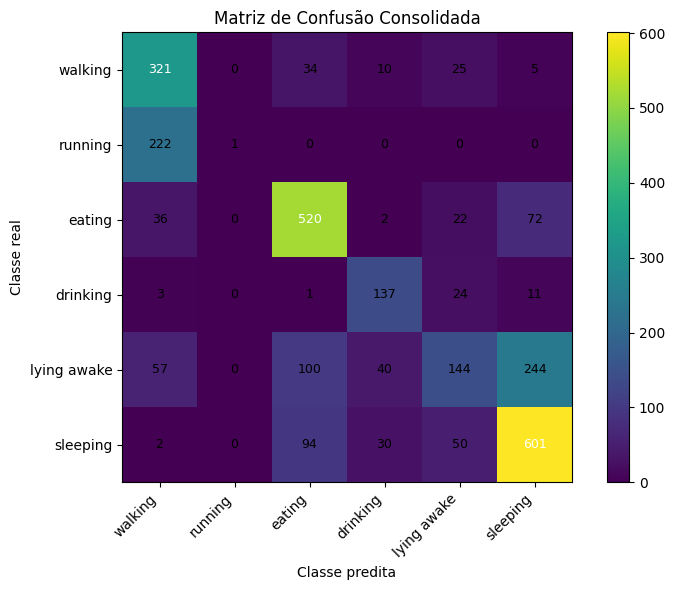

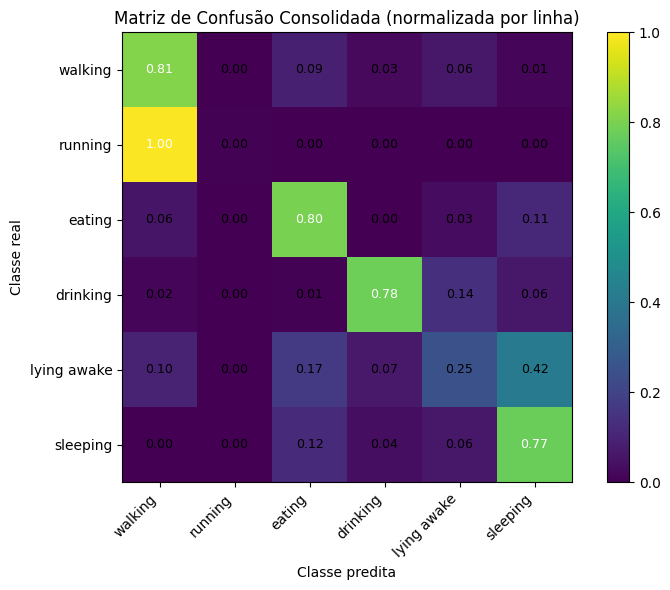


Arquivos salvos em:
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\classification_report_consolidated.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated_row_normalized.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\average_precision_per_class.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\fold_summary.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\global_summary.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated.png
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated_row_normalized.png


In [15]:
# =========================================================
# MATRIZ DE CONFUSÃO CONSOLIDADA + MÉTRICAS DE DESEMPENHO
# SlowFast - 5 folds
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold")
CLASS_JSON = RUNS_ROOT / "class_names.json"
OUTDIR = RUNS_ROOT / "consolidated_metrics"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# LOAD CLASS NAMES
# ---------------------------------------------------------

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
n_classes = len(class_names)

print("Classes:", class_names)

# ---------------------------------------------------------
# LOAD FOLD ARTIFACTS
# ---------------------------------------------------------

all_y_true = []
all_y_pred = []
all_probs = []
fold_summary = []

for fold in range(5):
    fold_dir = RUNS_ROOT / f"fold{fold}"
    art_path = fold_dir / "val_artifacts_best.npz"

    if not art_path.exists():
        print(f"[AVISO] Arquivo não encontrado: {art_path}")
        continue

    z = np.load(art_path, allow_pickle=True)

    y_true = z["y_true"].astype(int)
    y_pred = z["y_pred"].astype(int)
    probs = z["probs"]

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)
    all_probs.append(probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    fold_summary.append({
        "fold": fold,
        "n_samples": len(y_true),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

    print(f"Fold {fold}: n={len(y_true)} | acc={acc:.4f} | macro_f1={macro_f1:.4f}")

if len(all_y_true) == 0:
    raise RuntimeError("Nenhum val_artifacts_best.npz foi encontrado.")

# ---------------------------------------------------------
# CONSOLIDATE
# ---------------------------------------------------------

y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
probs_all = np.concatenate(all_probs)

print("\nTotal consolidado:")
print("y_true_all:", y_true_all.shape)
print("y_pred_all:", y_pred_all.shape)
print("probs_all :", probs_all.shape)

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------

acc_all = accuracy_score(y_true_all, y_pred_all)
macro_f1_all = f1_score(y_true_all, y_pred_all, average="macro")
weighted_f1_all = f1_score(y_true_all, y_pred_all, average="weighted")

print("\nResumo global:")
print(f"Accuracy   : {acc_all:.6f}")
print(f"Macro-F1   : {macro_f1_all:.6f}")
print(f"Weighted-F1: {weighted_f1_all:.6f}")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

report = classification_report(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_csv = OUTDIR / "classification_report_consolidated.csv"
report_df.to_csv(report_csv, encoding="utf-8-sig")

print("\nResultado por classe:")
display(report_df)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes)
)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv = OUTDIR / "confusion_matrix_consolidated.csv"
cm_df.to_csv(cm_csv, encoding="utf-8-sig")

# normalizada por linha
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
cm_norm_csv = OUTDIR / "confusion_matrix_consolidated_row_normalized.csv"
cm_norm_df.to_csv(cm_norm_csv, encoding="utf-8-sig")

print("\nMatriz de confusão consolidada:")
display(cm_df)

print("\nMatriz de confusão normalizada:")
display(cm_norm_df)

# ---------------------------------------------------------
# AP POR CLASSE + mAP
# ---------------------------------------------------------

Y_bin = label_binarize(y_true_all, classes=np.arange(n_classes))

ap_rows = []
aps = []

for c in range(n_classes):
    if Y_bin[:, c].sum() == 0:
        ap = np.nan
    else:
        ap = average_precision_score(Y_bin[:, c], probs_all[:, c])

    aps.append(ap)
    ap_rows.append({
        "class_idx": c,
        "class_name": class_names[c],
        "AP": ap
    })

ap_df = pd.DataFrame(ap_rows)
map_value = np.nanmean(aps)

ap_csv = OUTDIR / "average_precision_per_class.csv"
ap_df.to_csv(ap_csv, index=False, encoding="utf-8-sig")

print("\nAP por classe:")
display(ap_df)

print(f"\nmAP consolidado: {map_value:.6f}")

# ---------------------------------------------------------
# FOLD SUMMARY
# ---------------------------------------------------------

fold_summary_df = pd.DataFrame(fold_summary)
fold_summary_csv = OUTDIR / "fold_summary.csv"
fold_summary_df.to_csv(fold_summary_csv, index=False, encoding="utf-8-sig")

print("\nResumo por fold:")
display(fold_summary_df)

# ---------------------------------------------------------
# GLOBAL SUMMARY
# ---------------------------------------------------------

global_summary = pd.DataFrame([{
    "accuracy": acc_all,
    "macro_f1": macro_f1_all,
    "weighted_f1": weighted_f1_all,
    "mAP": map_value,
    **{f"AP_{row['class_name']}": row["AP"] for _, row in ap_df.iterrows()}
}])

global_summary_csv = OUTDIR / "global_summary.csv"
global_summary.to_csv(global_summary_csv, index=False, encoding="utf-8-sig")

print("\nResumo global:")
display(global_summary)

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------

ticks = np.arange(n_classes)

# matriz absoluta
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão Consolidada")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

thresh = cm.max() / 2 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=9
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
png_abs = OUTDIR / "confusion_matrix_consolidated.png"
plt.savefig(png_abs, dpi=200, bbox_inches="tight")
plt.show()

# matriz normalizada
plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
plt.title("Matriz de Confusão Consolidada (normalizada por linha)")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black",
            fontsize=9
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
png_norm = OUTDIR / "confusion_matrix_consolidated_row_normalized.png"
plt.savefig(png_norm, dpi=200, bbox_inches="tight")
plt.show()

print("\nArquivos salvos em:")
print(" -", report_csv)
print(" -", cm_csv)
print(" -", cm_norm_csv)
print(" -", ap_csv)
print(" -", fold_summary_csv)
print(" -", global_summary_csv)
print(" -", png_abs)
print(" -", png_norm)

## Benchmark SlowFast inference time

This cell applies the generic benchmarking function to the trained SlowFast model. It reuses a validation mini-batch, builds a function that returns the same slow/fast input pair, and measures the inference latency and throughput of the SlowFast visual baseline on the selected device.


In [19]:
# =========================================================
# FUNÇÃO GERAL PARA MEDIR TEMPO DE INFERÊNCIA
# =========================================================

import time
import numpy as np
import torch

def benchmark_inference(model, make_input_fn, device="cuda", n_warmup=20, n_runs=100, model_name="modelo"):
    """
    model: modelo PyTorch já carregado
    make_input_fn: função que retorna a entrada já no formato esperado pelo modelo
    device: "cuda" ou "cpu"
    """

    model.eval()
    model.to(device)

    # warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            x = make_input_fn()
            if isinstance(x, (list, tuple)):
                x = [t.to(device, non_blocking=True) for t in x]
            else:
                x = x.to(device, non_blocking=True)

            _ = model(x)

    if device.startswith("cuda"):
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    times = []
    batch_sizes = []

    with torch.no_grad():
        for _ in range(n_runs):
            x = make_input_fn()

            if isinstance(x, (list, tuple)):
                batch_size = x[0].shape[0]
                x = [t.to(device, non_blocking=True) for t in x]
            else:
                batch_size = x.shape[0]
                x = x.to(device, non_blocking=True)

            if device.startswith("cuda"):
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            _ = model(x)

            if device.startswith("cuda"):
                torch.cuda.synchronize()
            t1 = time.perf_counter()

            times.append(t1 - t0)
            batch_sizes.append(batch_size)

    times = np.array(times, dtype=np.float64)
    batch_sizes = np.array(batch_sizes, dtype=np.float64)

    time_per_batch = times.mean()
    std_per_batch = times.std()

    time_per_sample = (times / batch_sizes).mean()
    std_per_sample = (times / batch_sizes).std()

    fps = 1.0 / time_per_sample if time_per_sample > 0 else np.nan

    peak_mem_mb = None
    if device.startswith("cuda"):
        peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    n_params = sum(p.numel() for p in model.parameters())

    result = {
        "modelo": model_name,
        "device": device,
        "tempo_medio_batch_s": time_per_batch,
        "desvio_batch_s": std_per_batch,
        "tempo_medio_amostra_s": time_per_sample,
        "tempo_medio_amostra_ms": time_per_sample * 1000.0,
        "desvio_amostra_ms": std_per_sample * 1000.0,
        "fps_inferencia": fps,
        "memoria_max_gpu_mb": peak_mem_mb,
        "n_parametros": n_params,
    }

    print("\n========== RESULTADO ==========")
    for k, v in result.items():
        if isinstance(v, float):
            print(f"{k}: {v:.6f}")
        else:
            print(f"{k}: {v}")

    return result

## Benchmark DeGCN inference time for comparison

This cell benchmarks a trained DeGCN checkpoint using the same benchmarking strategy. It loads the DeGCN model implementation, restores the checkpoint, prepares skeleton input tensors from the YOLO-derived DeGCN dataset, and measures inference speed. The purpose is to compare computational cost between RGB-based SlowFast and skeleton-based DeGCN representations.


In [21]:
# =========================================================
# TEMPO DE INFERÊNCIA — SLOWFAST
# =========================================================

# pegue um batch do loader de validação
xb, yb, mb = next(iter(dl_val))

# função que sempre retorna o mesmo batch
def make_input_slowfast():
    return [xb[0].clone(), xb[1].clone()]

result_slowfast = benchmark_inference(
    model=model,
    make_input_fn=make_input_slowfast,
    device=DEVICE,
    n_warmup=20,
    n_runs=100,
    model_name="SlowFast"
)


========== RESULTADO ==========
modelo: SlowFast
device: cuda
tempo_medio_batch_s: 0.041225
desvio_batch_s: 0.000475
tempo_medio_amostra_s: 0.020612
tempo_medio_amostra_ms: 20.612412
desvio_amostra_ms: 0.237461
fps_inferencia: 48.514459
memoria_max_gpu_mb: 757.804199
n_parametros: 33658318


## Code cell 18

This cell is part of the SlowFast experimental pipeline and should be executed in sequence with the surrounding cells.


In [37]:
# =========================================================
# BENCHMARK DE INFERÊNCIA — DeGCN (checkpoint fold02)
# =========================================================

import sys
import time
import json
import numpy as np
import torch
from pathlib import Path

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ROOT_DEGCN = Path(r"F:\Doutorado\DeGCN_pytorch-main\DeGCN_pytorch-main")
CKPT_PATH  = Path(r"F:\Doutorado\experimentos\degcn\experiments\degcn_yolo_T15_5fold_temporal_blocks\fold02.pth")
DATA_PATH  = Path(r"F:\meus_dados_degcn_yolo_T15\data_valid.npy")
NAMES_PATH = Path(r"F:\meus_dados_degcn_yolo_T15\labels_mix_map.json")

BATCH_SIZE = 32
N_WARMUP = 20
N_RUNS = 100

for p in [ROOT_DEGCN, CKPT_PATH, DATA_PATH, NAMES_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

if str(ROOT_DEGCN) not in sys.path:
    sys.path.insert(0, str(ROOT_DEGCN))

# ---------------------------------------------------------
# IMPORT DO MODELO
# ---------------------------------------------------------

from model.degcn import Model

# ---------------------------------------------------------
# NÚMERO DE CLASSES
# ---------------------------------------------------------

with open(NAMES_PATH, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

NUM_CLASS = len(idx_to_class)

print("Classes:", idx_to_class)
print("NUM_CLASS:", NUM_CLASS)

# ---------------------------------------------------------
# CRIAR MODELO
# ---------------------------------------------------------

model_degcn = Model(
    num_class=NUM_CLASS,
    num_point=9,
    num_person=1,
    graph="graph.pig.Graph",
    graph_args={"strategy": "spatial"},
    in_channels=2
)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

# tenta diferentes formatos comuns
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

# remove prefixo "module." se existir
new_state = {}
for k, v in state_dict.items():
    nk = k.replace("module.", "")
    new_state[nk] = v

model_degcn.load_state_dict(new_state, strict=False)
model_degcn = model_degcn.to(DEVICE)
model_degcn.eval()

print("Modelo DeGCN carregado com sucesso.")

# ---------------------------------------------------------
# INPUT DE TESTE
# ---------------------------------------------------------

X_valid = np.load(DATA_PATH)
xb_degcn = torch.tensor(X_valid[:BATCH_SIZE], dtype=torch.float32)

print("Shape do batch:", xb_degcn.shape)

# ---------------------------------------------------------
# BENCHMARK
# ---------------------------------------------------------

with torch.no_grad():
    # warmup
    for _ in range(N_WARMUP):
        x = xb_degcn.to(DEVICE, non_blocking=True)
        _ = model_degcn(x)

if DEVICE.startswith("cuda"):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

times = []

with torch.no_grad():
    for _ in range(N_RUNS):
        x = xb_degcn.to(DEVICE, non_blocking=True)

        if DEVICE.startswith("cuda"):
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        _ = model_degcn(x)

        if DEVICE.startswith("cuda"):
            torch.cuda.synchronize()

        t1 = time.perf_counter()
        times.append(t1 - t0)

times = np.array(times, dtype=np.float64)

tempo_batch = times.mean()
tempo_amostra = tempo_batch / BATCH_SIZE
fps = 1.0 / tempo_amostra if tempo_amostra > 0 else np.nan

mem_mb = None
if DEVICE.startswith("cuda"):
    mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

n_params = sum(p.numel() for p in model_degcn.parameters())

print("\n========== RESULTADO DeGCN ==========")
print(f"Tempo médio por batch   : {tempo_batch:.6f} s")
print(f"Tempo médio por amostra : {tempo_amostra*1000:.6f} ms")
print(f"FPS inferência          : {fps:.3f}")
print(f"Desvio batch            : {times.std():.6f} s")
print(f"Memória máx. GPU        : {mem_mb:.3f} MB" if mem_mb is not None else "Memória máx. GPU: N/A")
print(f"Número de parâmetros    : {n_params}")

Classes: {0: 'walking', 1: 'running', 2: 'eating', 3: 'drinking', 4: 'lying awake', 5: 'sleeping'}
NUM_CLASS: 6


C:\Users\pedro\AppData\Local\Temp\ipykernel_19932\4235870502.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=DEVICE)


Modelo DeGCN carregado com sucesso.
Shape do batch: torch.Size([32, 2, 15, 9, 1])

========== RESULTADO DeGCN ==========
Tempo médio por batch   : 0.061172 s
Tempo médio por amostra : 1.911613 ms
FPS inferência          : 523.118
Desvio batch            : 0.002251 s
Memória máx. GPU        : 590.532 MB
Número de parâmetros    : 1320388


## Prepare the four-class SlowFast formulation

This section begins the four-class version of the SlowFast experiment. The goal is to aggregate related behaviors into broader categories so the visual baseline can be compared with the four-class skeleton-based experiments.


## Remap the SlowFast dataset from six classes to four classes

This cell converts the original six-class SlowFast dataset into a four-class formulation. Walking and running are merged into a locomotion-related class, while sleeping and lying-awake states are merged into a lying/resting class. The remapped CSV and label dictionary are saved under `merged_4classes/` for downstream fold generation and training.


In [2]:
# =========================================================
# SLOWFAST -> REMAPEAR PARA 4 CLASSES
# walking + running -> deslocando
# sleeping + lying awake -> deitado
# =========================================================

from pathlib import Path
import pandas as pd
import json

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
CSV_IN = ROOT / "slowfast_dataset_aligned.csv"

OUT_ROOT = ROOT / "merged_4classes"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

CSV_OUT = OUT_ROOT / "slowfast_dataset_4cls.csv"
MAP_OUT = OUT_ROOT / "labels_map_4cls.json"

df = pd.read_csv(CSV_IN)

print("Dataset original:", df.shape)
print(df["label_name"].value_counts())

# novo mapeamento
new_class_to_idx = {
    "deslocando": 0,
    "eating": 1,
    "drinking": 2,
    "deitado": 3,
}

def remap_label(lbl):
    if lbl in ["walking", "running"]:
        return "deslocando"
    elif lbl == "eating":
        return "eating"
    elif lbl == "drinking":
        return "drinking"
    elif lbl in ["sleeping", "lying awake"]:
        return "deitado"
    else:
        return None

df = df.copy()
df["label_name_4cls"] = df["label_name"].map(remap_label)
df["label_idx_4cls"] = df["label_name_4cls"].map(new_class_to_idx)

# manter só válidos
df4 = df[df["label_name_4cls"].notna()].copy().reset_index(drop=True)

# padronizar nomes finais
df4["label_name"] = df4["label_name_4cls"]
df4["label_idx"] = df4["label_idx_4cls"]

drop_cols = [c for c in ["label_name_4cls", "label_idx_4cls"] if c in df4.columns]
df4 = df4.drop(columns=drop_cols)

df4.to_csv(CSV_OUT, index=False, encoding="utf-8-sig")

with open(MAP_OUT, "w", encoding="utf-8") as f:
    json.dump(
        {
            "class_to_idx": new_class_to_idx,
            "idx_to_class": {str(v): k for k, v in new_class_to_idx.items()}
        },
        f,
        ensure_ascii=False,
        indent=2
    )

print("\n[OK] Dataset 4 classes salvo em:", CSV_OUT)
print(df4["label_name"].value_counts())
print("df4.shape =", df4.shape)

Dataset original: (2808, 9)
label_name
sleeping       777
eating         652
lying awake    585
walking        395
running        223
drinking       176
Name: count, dtype: int64

[OK] Dataset 4 classes salvo em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_dataset_4cls.csv
label_name
deitado       1362
eating         652
deslocando     618
drinking       176
Name: count, dtype: int64
df4.shape = (2808, 9)


## Create aligned temporal folds for the four-class dataset

This cell rebuilds the five temporal folds after label aggregation. It uses the original aligned fold assignments to preserve the same temporal separation while mapping the old sample indices to the new four-class dataset indices. The resulting train/validation CSV files and index arrays allow the four-class SlowFast experiment to remain directly comparable with the original temporal-block validation protocol.


In [4]:
# =========================================================
# CRIAR FOLDS ALINHADOS PARA 4 CLASSES
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes")
CSV_4CLS = ROOT / "slowfast_dataset_4cls.csv"

SPLITS_OLD = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\folds_aligned")
OUTDIR = ROOT / "folds_aligned"
OUTDIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_4CLS)
print("Dataset 4cls:", df.shape)

# mapa orig_idx -> novo idx
orig_to_new = {int(orig_idx): i for i, orig_idx in enumerate(df["orig_idx"].tolist())}

summary = []

for fold in range(5):
    tr_idx_old = np.load(SPLITS_OLD / f"fold{fold}_train_idx.npy")
    va_idx_old = np.load(SPLITS_OLD / f"fold{fold}_val_idx.npy")

    # recuperar os orig_idx correspondentes do dataset alinhado antigo
    df_old_train = pd.read_csv(SPLITS_OLD / f"fold{fold}_train.csv")
    df_old_val   = pd.read_csv(SPLITS_OLD / f"fold{fold}_val.csv")

    tr_orig = df_old_train["orig_idx"].to_numpy(dtype=np.int64)
    va_orig = df_old_val["orig_idx"].to_numpy(dtype=np.int64)

    tr_idx_new = np.array([orig_to_new[i] for i in tr_orig if int(i) in orig_to_new], dtype=np.int64)
    va_idx_new = np.array([orig_to_new[i] for i in va_orig if int(i) in orig_to_new], dtype=np.int64)

    df_tr = df.iloc[tr_idx_new].reset_index(drop=True)
    df_va = df.iloc[va_idx_new].reset_index(drop=True)

    df_tr.to_csv(OUTDIR / f"fold{fold}_train.csv", index=False, encoding="utf-8-sig")
    df_va.to_csv(OUTDIR / f"fold{fold}_val.csv", index=False, encoding="utf-8-sig")

    np.save(OUTDIR / f"fold{fold}_train_idx.npy", tr_idx_new)
    np.save(OUTDIR / f"fold{fold}_val_idx.npy", va_idx_new)

    summary.append({
        "fold": fold,
        "n_train": len(df_tr),
        "n_val": len(df_va),
    })

    print(f"\nFold {fold}")
    print("train:", df_tr.shape)
    print("val  :", df_va.shape)
    print("classes val:")
    print(df_va["label_name"].value_counts())

summary_df = pd.DataFrame(summary)
print("\nResumo:")
display(summary_df)

print("\n[OK] Folds 4 classes salvos em:", OUTDIR)

Dataset 4cls: (2808, 9)

Fold 0
train: (2430, 9)
val  : (378, 9)
classes val:
label_name
deitado       216
deslocando     83
eating         73
drinking        6
Name: count, dtype: int64

Fold 1
train: (2318, 9)
val  : (490, 9)
classes val:
label_name
deitado       294
eating        154
deslocando     31
drinking       11
Name: count, dtype: int64

Fold 2
train: (2220, 9)
val  : (588, 9)
classes val:
label_name
deitado       384
eating        115
drinking       68
deslocando     21
Name: count, dtype: int64

Fold 3
train: (2070, 9)
val  : (738, 9)
classes val:
label_name
deitado       364
eating        266
drinking       81
deslocando     27
Name: count, dtype: int64

Fold 4
train: (2194, 9)
val  : (614, 9)
classes val:
label_name
deslocando    456
deitado       104
eating         44
drinking       10
Name: count, dtype: int64

Resumo:


,fold,n_train,n_val
0,0,2430,378
1,1,2318,490
2,2,2220,588
3,3,2070,738
4,4,2194,614



[OK] Folds 4 classes salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\folds_aligned


## Training and artifact generation for the four-class experiment

This section groups the cells that train SlowFast models for the four-class setting and save the corresponding experimental artifacts.


## Train SlowFast on the four-class dataset across five folds

This cell defines the dataset and training loop for the four-class SlowFast experiment. It reads the remapped fold CSV files, constructs slow and fast pathways for each RGB clip, initializes a SlowFast R50 model with a four-class output head, trains each fold, evaluates validation performance, and saves metrics, predictions, confusion matrices, class names, checkpoints, and training histories.


In [8]:
# =========================================================
# SLOWFAST 4 CLASSES — DATASET + TREINO 5 FOLDS
# walking+running=deslocando | sleeping+lying awake=deitado
# =========================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from pytorchvideo.models.hub import slowfast_r50

# =========================================================
# DATASET
# =========================================================

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
            frames.append(img)

        return np.stack(frames, axis=0)  # (T, C, H, W)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_clip = self._load_src_clip(row["clip_dir"])   # (15, C, H, W)

        fast = src_clip[self.fast_idx]                    # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))          # (C, 32, H, W)
        slow = fast[:, self.slow_idx, :, :]              # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)
        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }
        return [slow, fast], y, meta

def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

print("✅ Dataset carregado")

# =========================================================
# CONFIG
# =========================================================

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes")
FOLDS_DIR = ROOT / "folds_aligned"
SAVE_ROOT = ROOT / "slowfast_runs_4cls_5fold"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

LABELS_MAP = ROOT / "labels_map_4cls.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2
NUM_WORKERS = 0
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 224
SRC_FRAMES = 15
FAST_FRAMES = 32
SLOW_FRAMES = 8

print("DEVICE:", DEVICE)

# =========================================================
# CLASSES
# =========================================================

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

with open(SAVE_ROOT / "class_names.json", "w", encoding="utf-8") as f:
    json.dump({"idx_to_class": {str(i): c for i, c in enumerate(class_names)}}, f, ensure_ascii=False, indent=2)

# =========================================================
# LOOP 5 FOLDS
# =========================================================

global_summary = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    csv_train = FOLDS_DIR / f"fold{fold}_train.csv"
    csv_val   = FOLDS_DIR / f"fold{fold}_val.csv"

    ds_train = PigSlowFastDataset(csv_train, SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)
    ds_val   = PigSlowFastDataset(csv_val,   SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)

    dl_train = DataLoader(
        ds_train, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )
    dl_val = DataLoader(
        ds_val, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )

    print("Train:", len(ds_train))
    print("Val  :", len(ds_val))

    df_train = pd.read_csv(csv_train)
    counts = df_train["label_idx"].value_counts().sort_index()

    weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for c in range(NUM_CLASSES):
        n = counts.get(c, 1)
        weights[c] = len(df_train) / (NUM_CLASSES * n)

    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print("Class weights:", weights)

    model = slowfast_r50(pretrained=False)
    in_features = model.blocks[-1].proj.in_features
    model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_macro_f1 = -1.0
    best_epoch = -1
    history = []

    fold_dir = SAVE_ROOT / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n[FOLD {fold}] EPOCH {epoch+1}/{EPOCHS}")

        model.train()
        train_losses = []

        for i, (x, y, _) in enumerate(dl_train):
            if i % 50 == 0:
                print(f"[TRAIN] batch {i}/{len(dl_train)}")

            x = [t.to(DEVICE, non_blocking=True) for t in x]
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan

        model.eval()
        y_true = []
        y_pred = []
        probs_all = []
        meta_all = []

        with torch.no_grad():
            for i, (x, y, meta_batch) in enumerate(dl_val):
                if i % 50 == 0:
                    print(f"[VAL] batch {i}/{len(dl_val)}")

                x = [t.to(DEVICE, non_blocking=True) for t in x]

                logits = model(x)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = probs.argmax(axis=1)

                y_true.append(y.numpy())
                y_pred.append(pred)
                probs_all.append(probs)
                meta_all.extend(meta_batch)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        probs_all = np.concatenate(probs_all)

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")
        epoch_time = time.time() - t0

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_acc": acc,
            "val_macro_f1": macro_f1,
            "val_weighted_f1": weighted_f1,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[FOLD {fold}] epoch={epoch+1} | "
            f"loss={train_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"macro_f1={macro_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        scheduler.step(macro_f1)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1

            print(f"🔥 [FOLD {fold}] Novo melhor modelo na época {best_epoch} (macro-F1={best_macro_f1:.4f})")

            torch.save(model.state_dict(), fold_dir / "best.pt")

            np.savez_compressed(
                fold_dir / "val_artifacts_best.npz",
                y_true=y_true,
                y_pred=y_pred,
                probs=probs_all
            )

            pd.DataFrame(meta_all).to_csv(
                fold_dir / "meta_val_best.csv",
                index=False,
                encoding="utf-8-sig"
            )

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
            pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
                fold_dir / "confusion_matrix_best.csv",
                encoding="utf-8-sig"
            )

            rep = classification_report(
                y_true, y_pred,
                labels=np.arange(NUM_CLASSES),
                target_names=class_names,
                output_dict=True,
                zero_division=0
            )
            pd.DataFrame(rep).T.to_csv(
                fold_dir / "classification_report_best.csv",
                encoding="utf-8-sig"
            )

            with open(fold_dir / "summary_best.json", "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "fold": fold,
                        "best_epoch": best_epoch,
                        "best_val_acc": acc,
                        "best_val_macro_f1": macro_f1,
                        "best_val_weighted_f1": weighted_f1,
                        "n_train": len(ds_train),
                        "n_val": len(ds_val),
                        "class_names": class_names,
                    },
                    f,
                    ensure_ascii=False,
                    indent=2
                )

        pd.DataFrame(history).to_csv(
            fold_dir / "history.csv",
            index=False,
            encoding="utf-8-sig"
        )

    global_summary.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    })

global_summary_df = pd.DataFrame(global_summary)
global_summary_df.to_csv(
    SAVE_ROOT / "global_summary_folds.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n[OK] TREINAMENTO 4 CLASSES FINALIZADO")
display(global_summary_df)
print("Artefatos salvos em:", SAVE_ROOT)

✅ Dataset carregado
DEVICE: cuda
Classes: ['deslocando', 'eating', 'drinking', 'deitado']

FOLD 0
Train: 2430
Val  : 378
Class weights: tensor([1.1355, 1.0492, 3.5735, 0.5301], device='cuda:0')

[FOLD 0] EPOCH 1/10
[TRAIN] batch 0/1215
[TRAIN] batch 50/1215
[TRAIN] batch 100/1215
[TRAIN] batch 150/1215
[TRAIN] batch 200/1215
[TRAIN] batch 250/1215
[TRAIN] batch 300/1215
[TRAIN] batch 350/1215
[TRAIN] batch 400/1215
[TRAIN] batch 450/1215
[TRAIN] batch 500/1215
[TRAIN] batch 550/1215
[TRAIN] batch 600/1215
[TRAIN] batch 650/1215
[TRAIN] batch 700/1215
[TRAIN] batch 750/1215
[TRAIN] batch 800/1215
[TRAIN] batch 850/1215
[TRAIN] batch 900/1215
[TRAIN] batch 950/1215
[TRAIN] batch 1000/1215
[TRAIN] batch 1050/1215
[TRAIN] batch 1100/1215
[TRAIN] batch 1150/1215
[TRAIN] batch 1200/1215
[VAL] batch 0/189
[VAL] batch 50/189
[VAL] batch 100/189
[VAL] batch 150/189
[FOLD 0] epoch=1 | loss=0.8736 | acc=0.4603 | macro_f1=0.3964 | weighted_f1=0.4785 | time=623.1s
🔥 [FOLD 0] Novo melhor modelo na é

,fold,best_epoch,best_macro_f1,n_train,n_val
0,0,9,0.586512,2430,378
1,1,8,0.740527,2318,490
2,2,5,0.709173,2220,588
3,3,5,0.801178,2070,738
4,4,10,0.638658,2194,614


Artefatos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold


## Plot training curves for each four-class fold

This cell reads the saved training histories from the four-class SlowFast runs and visualizes the optimization process. For each fold, it plots training loss and validation metrics across epochs. These plots help assess convergence, instability, and possible overfitting across temporal folds.



Fold 0


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,0,1,0.873626,0.460317,0.396389,0.478460,0.0001,623.076064
1,0,2,0.703209,0.484127,0.438032,0.519152,0.0001,271.879037
2,0,3,0.563421,0.518519,0.438263,0.552757,0.0001,276.639045
3,0,4,0.501177,0.632275,0.472166,0.653034,0.0001,281.162932
4,0,5,0.446599,0.470899,0.459549,0.478343,0.0001,282.501264


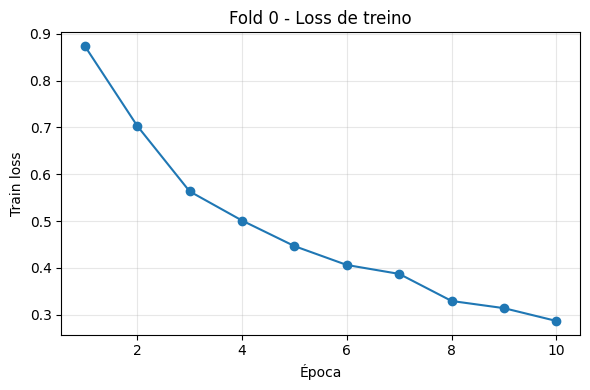

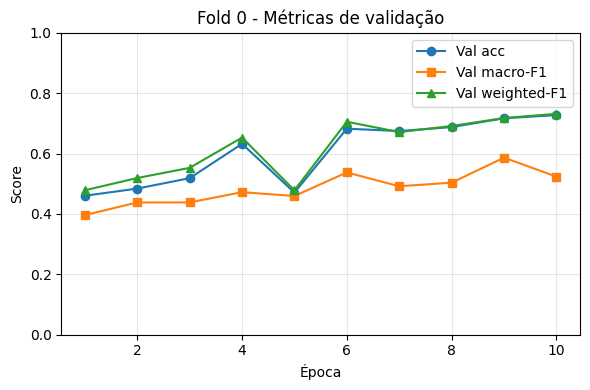


Fold 1


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,1,1,0.884390,0.477551,0.446824,0.475780,0.0001,285.199281
1,1,2,0.727824,0.683673,0.597636,0.703027,0.0001,280.227744
2,1,3,0.605562,0.681633,0.551916,0.661746,0.0001,278.523431
3,1,4,0.530069,0.777551,0.639122,0.777881,0.0001,281.594397
4,1,5,0.490897,0.697959,0.588802,0.704860,0.0001,271.141113


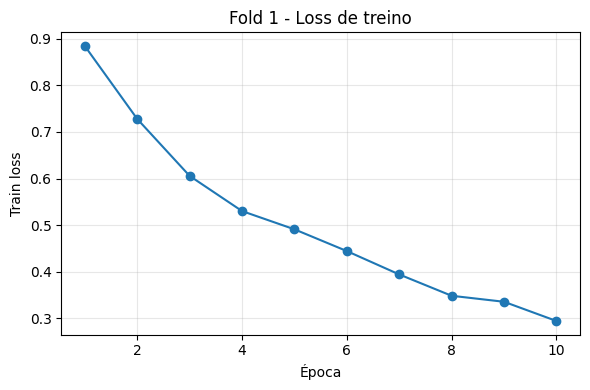

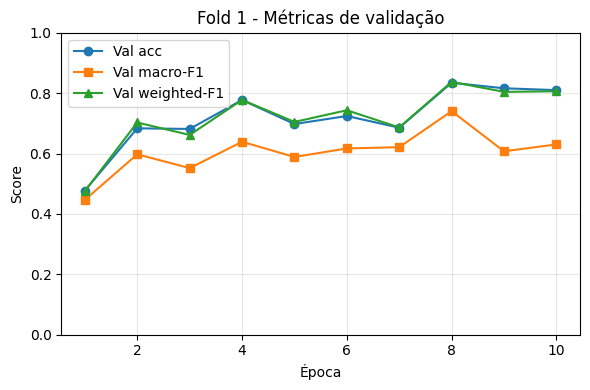


Fold 2


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,2,1,0.905470,0.748299,0.564498,0.744419,0.0001,260.598768
1,2,2,0.693699,0.760204,0.617175,0.762621,0.0001,260.301450
2,2,3,0.590959,0.722789,0.564743,0.726722,0.0001,260.133015
3,2,4,0.511320,0.846939,0.660036,0.840298,0.0001,260.593665
4,2,5,0.468799,0.841837,0.709173,0.844300,0.0001,259.823075


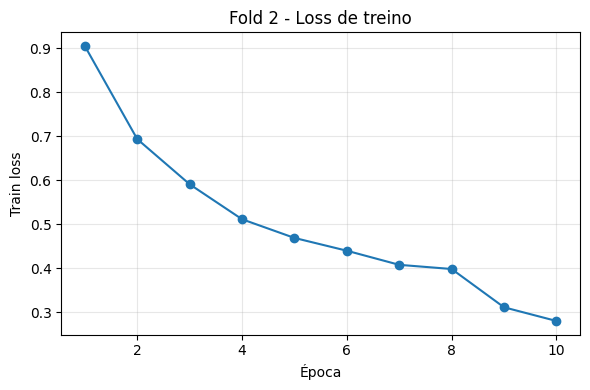

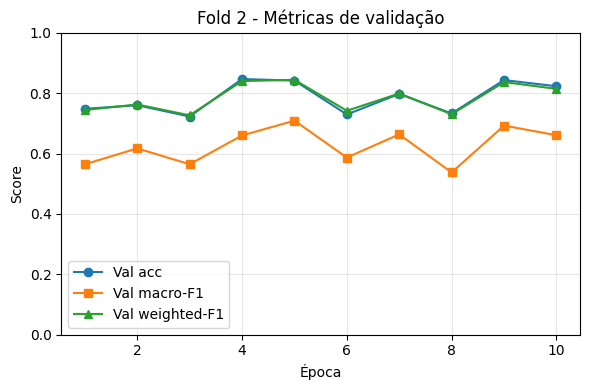


Fold 3


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,3,1,0.922086,0.677507,0.484099,0.640999,0.0001,254.086348
1,3,2,0.766151,0.791328,0.682089,0.783917,0.0001,253.467731
2,3,3,0.668601,0.860434,0.708934,0.854027,0.0001,253.619269
3,3,4,0.593183,0.849593,0.752720,0.842451,0.0001,253.488492
4,3,5,0.557071,0.861789,0.801178,0.858895,0.0001,254.074893


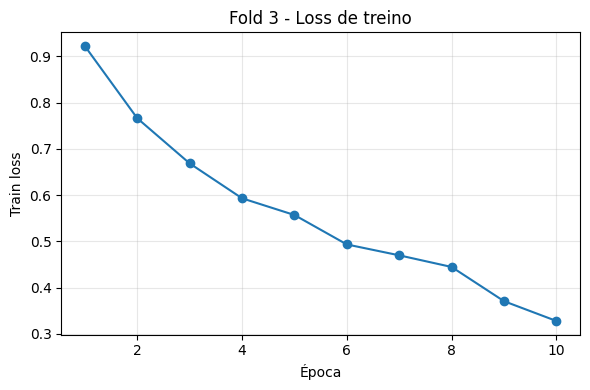

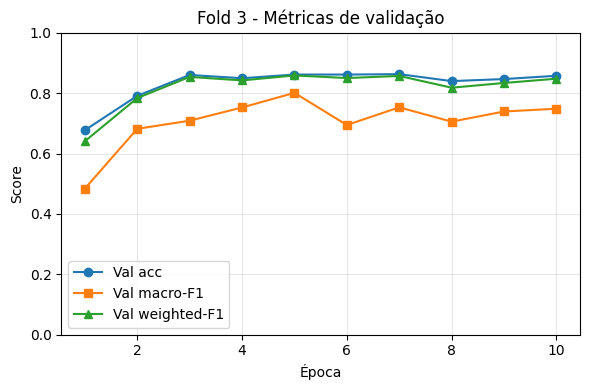


Fold 4


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,4,1,0.907951,0.780130,0.456539,0.746181,0.0001,259.520692
1,4,2,0.737625,0.801303,0.431349,0.754474,0.0001,259.820140
2,4,3,0.654497,0.827362,0.480882,0.809338,0.0001,265.033522
3,4,4,0.547142,0.791531,0.375266,0.733737,0.0001,258.716077
4,4,5,0.519033,0.819218,0.546199,0.802088,0.0001,259.440558


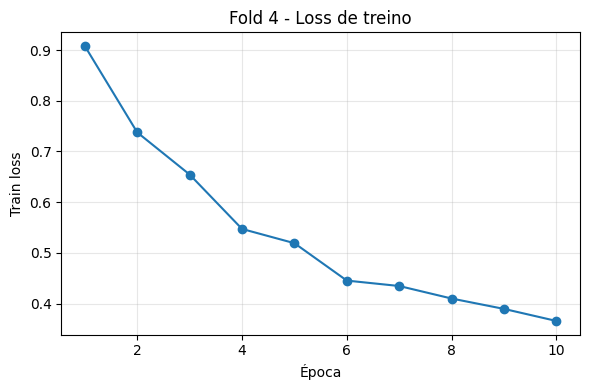

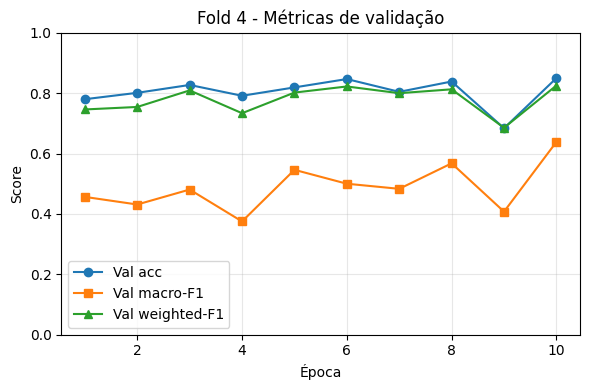

In [10]:
# =========================================================
# GRÁFICOS DE TREINO POR FOLD
# =========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold")

for fold in range(5):
    hist_path = RUNS_ROOT / f"fold{fold}" / "history.csv"
    if not hist_path.exists():
        print(f"[AVISO] Não encontrado: {hist_path}")
        continue

    df = pd.read_csv(hist_path)

    print(f"\nFold {fold}")
    display(df.head())

    # Loss de treino
    plt.figure(figsize=(6, 4))
    plt.plot(df["epoch"], df["train_loss"], marker="o")
    plt.title(f"Fold {fold} - Loss de treino")
    plt.xlabel("Época")
    plt.ylabel("Train loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Métricas de validação
    plt.figure(figsize=(6, 4))
    plt.plot(df["epoch"], df["val_acc"], marker="o", label="Val acc")
    plt.plot(df["epoch"], df["val_macro_f1"], marker="s", label="Val macro-F1")
    plt.plot(df["epoch"], df["val_weighted_f1"], marker="^", label="Val weighted-F1")
    plt.title(f"Fold {fold} - Métricas de validação")
    plt.xlabel("Época")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Consolidate final metrics for the four-class SlowFast experiment

This cell aggregates fold-level predictions from the four-class SlowFast runs. It computes global metrics, classification reports, average precision scores, raw and normalized confusion matrices, and exports consolidated tables and figures. The resulting files are used to summarize the final four-class visual-baseline performance.


Classes: ['deslocando', 'eating', 'drinking', 'deitado']

=== MÉTRICAS GLOBAIS ===
Accuracy      : 0.8308
Macro-F1      : 0.8083
Weighted-F1   : 0.8317

=== CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
deslocando,0.862285,0.891586,0.876691,618.00000
eating,0.750693,0.831288,0.788937,652.00000
drinking,0.700535,0.744318,0.721763,176.00000
deitado,0.880159,0.814244,0.845919,1362.00000
accuracy,0.830840,0.830840,0.830840,0.83084
macro avg,0.798418,0.820359,0.808328,2808.00000
weighted avg,0.834905,0.830840,0.831679,2808.00000



=== MATRIZ DE CONFUSÃO ===


,deslocando,eating,drinking,deitado
deslocando,551,37,7,23
eating,18,542,1,91
drinking,8,0,131,37
deitado,62,143,48,1109



=== MATRIZ NORMALIZADA ===


,deslocando,eating,drinking,deitado
deslocando,0.891586,0.059871,0.011327,0.037217
eating,0.027607,0.831288,0.001534,0.139571
drinking,0.045455,0.000000,0.744318,0.210227
deitado,0.045521,0.104993,0.035242,0.814244


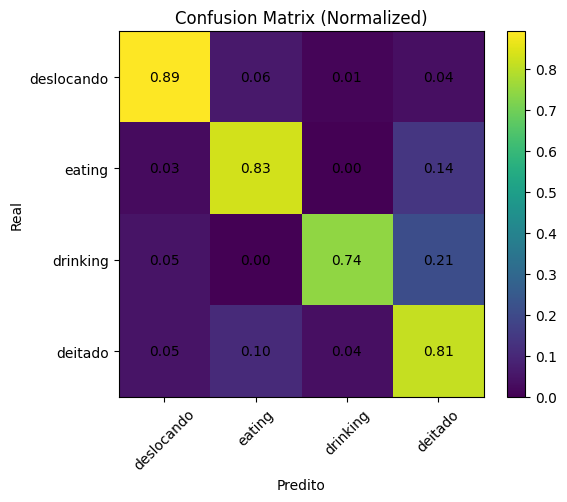


=== AP por classe ===


,class_idx,class_name,AP
0,0,deslocando,0.928716
1,1,eating,0.823384
2,2,drinking,0.713149
3,3,deitado,0.913658



mAP: 0.8447

=== RESUMO GLOBAL FINAL ===


,accuracy,macro_f1,weighted_f1,mAP,AP_deslocando,AP_eating,AP_drinking,AP_deitado
0,0.83084,0.808328,0.831679,0.844727,0.928716,0.823384,0.713149,0.913658



[OK] Tudo salvo em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold\consolidated_metrics


In [15]:
# =========================================================
# CONSOLIDAÇÃO FINAL — SLOWFAST 4 CLASSES
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold")
CLASS_JSON = RUNS_ROOT / "class_names.json"

OUTDIR = RUNS_ROOT / "consolidated_metrics"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# CLASSES
# ---------------------------------------------------------

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
n_classes = len(class_names)

print("Classes:", class_names)

# ---------------------------------------------------------
# CARREGAR TODOS OS FOLDS
# ---------------------------------------------------------

all_y_true = []
all_y_pred = []
all_probs = []
fold_summary = []

for fold in range(5):
    fold_dir = RUNS_ROOT / f"fold{fold}"
    art_path = fold_dir / "val_artifacts_best.npz"

    if not art_path.exists():
        print(f"[AVISO] Arquivo não encontrado: {art_path}")
        continue

    z = np.load(art_path, allow_pickle=True)
    y_true = z["y_true"].astype(int)
    y_pred = z["y_pred"].astype(int)
    probs = z["probs"]

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)
    all_probs.append(probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    fold_summary.append({
        "fold": fold,
        "n_samples": len(y_true),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

# ---------------------------------------------------------
# CONCATENAR
# ---------------------------------------------------------

y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
probs_all = np.concatenate(all_probs)

# ---------------------------------------------------------
# MÉTRICAS GLOBAIS
# ---------------------------------------------------------

acc_all = accuracy_score(y_true_all, y_pred_all)
macro_f1_all = f1_score(y_true_all, y_pred_all, average="macro")
weighted_f1_all = f1_score(y_true_all, y_pred_all, average="weighted")

print("\n=== MÉTRICAS GLOBAIS ===")
print(f"Accuracy      : {acc_all:.4f}")
print(f"Macro-F1      : {macro_f1_all:.4f}")
print(f"Weighted-F1   : {weighted_f1_all:.4f}")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

report = classification_report(
    y_true_all, y_pred_all,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df.to_csv(OUTDIR / "classification_report_consolidated.csv", encoding="utf-8-sig")

print("\n=== CLASSIFICATION REPORT ===")
display(report_df)

# ---------------------------------------------------------
# MATRIZ DE CONFUSÃO
# ---------------------------------------------------------

cm = confusion_matrix(y_true_all, y_pred_all, labels=np.arange(n_classes))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(OUTDIR / "confusion_matrix_consolidated.csv", encoding="utf-8-sig")

print("\n=== MATRIZ DE CONFUSÃO ===")
display(cm_df)

# ---------------------------------------------------------
# MATRIZ NORMALIZADA
# ---------------------------------------------------------

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
cm_norm_df.to_csv(OUTDIR / "confusion_matrix_normalized.csv", encoding="utf-8-sig")

print("\n=== MATRIZ NORMALIZADA ===")
display(cm_norm_df)

# ---------------------------------------------------------
# PLOT MATRIZ
# ---------------------------------------------------------

plt.figure(figsize=(6,5))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Confusion Matrix (Normalized)")
plt.colorbar()

plt.xticks(np.arange(n_classes), class_names, rotation=45)
plt.yticks(np.arange(n_classes), class_names)

for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# mAP (AP por classe)
# ---------------------------------------------------------

Y_bin = label_binarize(y_true_all, classes=np.arange(n_classes))

aps = []
ap_rows = []

for c in range(n_classes):
    if Y_bin[:, c].sum() == 0:
        ap = np.nan
    else:
        ap = average_precision_score(Y_bin[:, c], probs_all[:, c])

    aps.append(ap)
    ap_rows.append({
        "class_idx": c,
        "class_name": class_names[c],
        "AP": ap
    })

ap_df = pd.DataFrame(ap_rows)
ap_df.to_csv(OUTDIR / "average_precision_per_class.csv", index=False, encoding="utf-8-sig")

map_value = np.nanmean(aps)

print("\n=== AP por classe ===")
display(ap_df)

print(f"\nmAP: {map_value:.4f}")

# ---------------------------------------------------------
# RESUMO GLOBAL
# ---------------------------------------------------------

global_summary = pd.DataFrame([{
    "accuracy": acc_all,
    "macro_f1": macro_f1_all,
    "weighted_f1": weighted_f1_all,
    "mAP": map_value,
    **{f"AP_{row['class_name']}": row["AP"] for _, row in ap_df.iterrows()}
}])

global_summary.to_csv(OUTDIR / "global_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== RESUMO GLOBAL FINAL ===")
display(global_summary)

# ---------------------------------------------------------
# SALVAR FOLDS
# ---------------------------------------------------------

fold_summary_df = pd.DataFrame(fold_summary)
fold_summary_df.to_csv(OUTDIR / "fold_summary.csv", index=False, encoding="utf-8-sig")

print("\n[OK] Tudo salvo em:", OUTDIR)

## Four-class SlowFast experiment with 50 epochs

This section marks an additional four-class SlowFast training configuration using a longer training schedule. It is intended to evaluate whether increasing the number of epochs improves validation performance or changes class-level behavior.


## Train the four-class SlowFast model with the longer schedule

This cell repeats the four-class SlowFast five-fold training pipeline using the longer configuration. It preserves the same dataset structure and fold protocol while extending the training duration. The saved artifacts allow direct comparison with the shorter four-class training configuration.


In [1]:
# =========================================================
# SLOWFAST 4 CLASSES — DATASET + TREINO 5 FOLDS
# walking+running=deslocando | sleeping+lying awake=deitado
# =========================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from pytorchvideo.models.hub import slowfast_r50

# =========================================================
# DATASET
# =========================================================

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
            frames.append(img)

        return np.stack(frames, axis=0)  # (T, C, H, W)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_clip = self._load_src_clip(row["clip_dir"])   # (15, C, H, W)

        fast = src_clip[self.fast_idx]                    # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))          # (C, 32, H, W)
        slow = fast[:, self.slow_idx, :, :]              # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)
        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }
        return [slow, fast], y, meta

def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

print("✅ Dataset carregado")

# =========================================================
# CONFIG
# =========================================================

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes")
FOLDS_DIR = ROOT / "folds_aligned"
SAVE_ROOT = ROOT / "slowfast_runs_4cls_5fold"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

LABELS_MAP = ROOT / "labels_map_4cls.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
NUM_WORKERS = 0
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 224
SRC_FRAMES = 15
FAST_FRAMES = 32
SLOW_FRAMES = 8

print("DEVICE:", DEVICE)

# =========================================================
# CLASSES
# =========================================================

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

with open(SAVE_ROOT / "class_names.json", "w", encoding="utf-8") as f:
    json.dump({"idx_to_class": {str(i): c for i, c in enumerate(class_names)}}, f, ensure_ascii=False, indent=2)

# =========================================================
# LOOP 5 FOLDS
# =========================================================

global_summary = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    csv_train = FOLDS_DIR / f"fold{fold}_train.csv"
    csv_val   = FOLDS_DIR / f"fold{fold}_val.csv"

    ds_train = PigSlowFastDataset(csv_train, SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)
    ds_val   = PigSlowFastDataset(csv_val,   SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)

    dl_train = DataLoader(
        ds_train, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )
    dl_val = DataLoader(
        ds_val, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn
    )

    print("Train:", len(ds_train))
    print("Val  :", len(ds_val))

    df_train = pd.read_csv(csv_train)
    counts = df_train["label_idx"].value_counts().sort_index()

    weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for c in range(NUM_CLASSES):
        n = counts.get(c, 1)
        weights[c] = len(df_train) / (NUM_CLASSES * n)

    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print("Class weights:", weights)

    model = slowfast_r50(pretrained=False)
    in_features = model.blocks[-1].proj.in_features
    model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_macro_f1 = -1.0
    best_epoch = -1
    history = []

    fold_dir = SAVE_ROOT / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n[FOLD {fold}] EPOCH {epoch+1}/{EPOCHS}")

        model.train()
        train_losses = []

        for i, (x, y, _) in enumerate(dl_train):
            if i % 50 == 0:
                print(f"[TRAIN] batch {i}/{len(dl_train)}")

            x = [t.to(DEVICE, non_blocking=True) for t in x]
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan

        model.eval()
        y_true = []
        y_pred = []
        probs_all = []
        meta_all = []

        with torch.no_grad():
            for i, (x, y, meta_batch) in enumerate(dl_val):
                if i % 50 == 0:
                    print(f"[VAL] batch {i}/{len(dl_val)}")

                x = [t.to(DEVICE, non_blocking=True) for t in x]

                logits = model(x)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = probs.argmax(axis=1)

                y_true.append(y.numpy())
                y_pred.append(pred)
                probs_all.append(probs)
                meta_all.extend(meta_batch)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        probs_all = np.concatenate(probs_all)

        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")
        epoch_time = time.time() - t0

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_acc": acc,
            "val_macro_f1": macro_f1,
            "val_weighted_f1": weighted_f1,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[FOLD {fold}] epoch={epoch+1} | "
            f"loss={train_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"macro_f1={macro_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        scheduler.step(macro_f1)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1

            print(f"🔥 [FOLD {fold}] Novo melhor modelo na época {best_epoch} (macro-F1={best_macro_f1:.4f})")

            torch.save(model.state_dict(), fold_dir / "best.pt")

            np.savez_compressed(
                fold_dir / "val_artifacts_best.npz",
                y_true=y_true,
                y_pred=y_pred,
                probs=probs_all
            )

            pd.DataFrame(meta_all).to_csv(
                fold_dir / "meta_val_best.csv",
                index=False,
                encoding="utf-8-sig"
            )

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
            pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
                fold_dir / "confusion_matrix_best.csv",
                encoding="utf-8-sig"
            )

            rep = classification_report(
                y_true, y_pred,
                labels=np.arange(NUM_CLASSES),
                target_names=class_names,
                output_dict=True,
                zero_division=0
            )
            pd.DataFrame(rep).T.to_csv(
                fold_dir / "classification_report_best.csv",
                encoding="utf-8-sig"
            )

            with open(fold_dir / "summary_best.json", "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "fold": fold,
                        "best_epoch": best_epoch,
                        "best_val_acc": acc,
                        "best_val_macro_f1": macro_f1,
                        "best_val_weighted_f1": weighted_f1,
                        "n_train": len(ds_train),
                        "n_val": len(ds_val),
                        "class_names": class_names,
                    },
                    f,
                    ensure_ascii=False,
                    indent=2
                )

        pd.DataFrame(history).to_csv(
            fold_dir / "history.csv",
            index=False,
            encoding="utf-8-sig"
        )

    global_summary.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    })

global_summary_df = pd.DataFrame(global_summary)
global_summary_df.to_csv(
    SAVE_ROOT / "global_summary_folds.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n[OK] TREINAMENTO 4 CLASSES FINALIZADO")
display(global_summary_df)
print("Artefatos salvos em:", SAVE_ROOT)

✅ Dataset carregado
DEVICE: cuda
Classes: ['deslocando', 'eating', 'drinking', 'deitado']

FOLD 0
Train: 2430
Val  : 378
Class weights: tensor([1.1355, 1.0492, 3.5735, 0.5301], device='cuda:0')

[FOLD 0] EPOCH 1/50
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608
[TRAIN] batch 500/608
[TRAIN] batch 550/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[VAL] batch 50/95
[FOLD 0] epoch=1 | loss=0.7304 | acc=0.5873 | macro_f1=0.5378 | weighted_f1=0.6082 | time=543.2s
🔥 [FOLD 0] Novo melhor modelo na época 1 (macro-F1=0.5378)

[FOLD 0] EPOCH 2/50
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608
[TRAIN] batch 500/608
[TRAIN] batch 550/608
[TRAIN] batch 600/608
[VAL] b

,fold,best_epoch,best_macro_f1,n_train,n_val
0,0,33,0.646702,2430,378
1,1,10,0.861971,2318,490
2,2,12,0.819806,2220,588
3,3,37,0.867660,2070,738
4,4,6,0.567550,2194,614


Artefatos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold


## Consolidate the longer four-class SlowFast experiment

This cell consolidates the fold-level outputs from the longer four-class experiment. It computes the same summary metrics, reports, and confusion matrices used previously so that the effect of the longer training schedule can be evaluated consistently.


Classes: ['deslocando', 'eating', 'drinking', 'deitado']

=== MÉTRICAS GLOBAIS ===
Accuracy      : 0.8746
Macro-F1      : 0.8533
Weighted-F1   : 0.8748

=== CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
deslocando,0.880691,0.907767,0.894024,618.000000
eating,0.834302,0.880368,0.856716,652.000000
drinking,0.777143,0.772727,0.774929,176.000000
deitado,0.905963,0.870044,0.887640,1362.000000
accuracy,0.874644,0.874644,0.874644,0.874644
macro avg,0.849525,0.857727,0.853327,2808.000000
weighted avg,0.875688,0.874644,0.874800,2808.000000



=== MATRIZ DE CONFUSÃO ===


,deslocando,eating,drinking,deitado
deslocando,561,18,8,31
eating,20,574,1,57
drinking,3,2,136,35
deitado,53,94,30,1185



=== MATRIZ NORMALIZADA ===


,deslocando,eating,drinking,deitado
deslocando,0.907767,0.029126,0.012945,0.050162
eating,0.030675,0.880368,0.001534,0.087423
drinking,0.017045,0.011364,0.772727,0.198864
deitado,0.038913,0.069016,0.022026,0.870044


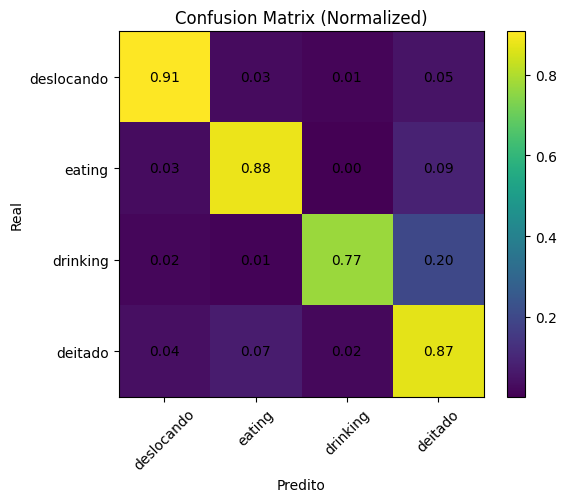


=== AP por classe ===


,class_idx,class_name,AP
0,0,deslocando,0.937499
1,1,eating,0.927553
2,2,drinking,0.748059
3,3,deitado,0.950091



mAP: 0.8908

=== RESUMO GLOBAL FINAL ===


,accuracy,macro_f1,weighted_f1,mAP,AP_deslocando,AP_eating,AP_drinking,AP_deitado
0,0.874644,0.853327,0.8748,0.890801,0.937499,0.927553,0.748059,0.950091



[OK] Tudo salvo em: F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold\consolidated_metrics


In [1]:
# =========================================================
# CONSOLIDAÇÃO FINAL — SLOWFAST 4 CLASSES
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold")
CLASS_JSON = RUNS_ROOT / "class_names.json"

OUTDIR = RUNS_ROOT / "consolidated_metrics"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# CLASSES
# ---------------------------------------------------------

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
n_classes = len(class_names)

print("Classes:", class_names)

# ---------------------------------------------------------
# CARREGAR TODOS OS FOLDS
# ---------------------------------------------------------

all_y_true = []
all_y_pred = []
all_probs = []
fold_summary = []

for fold in range(5):
    fold_dir = RUNS_ROOT / f"fold{fold}"
    art_path = fold_dir / "val_artifacts_best.npz"

    if not art_path.exists():
        print(f"[AVISO] Arquivo não encontrado: {art_path}")
        continue

    z = np.load(art_path, allow_pickle=True)
    y_true = z["y_true"].astype(int)
    y_pred = z["y_pred"].astype(int)
    probs = z["probs"]

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)
    all_probs.append(probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    fold_summary.append({
        "fold": fold,
        "n_samples": len(y_true),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

# ---------------------------------------------------------
# CONCATENAR
# ---------------------------------------------------------

y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
probs_all = np.concatenate(all_probs)

# ---------------------------------------------------------
# MÉTRICAS GLOBAIS
# ---------------------------------------------------------

acc_all = accuracy_score(y_true_all, y_pred_all)
macro_f1_all = f1_score(y_true_all, y_pred_all, average="macro")
weighted_f1_all = f1_score(y_true_all, y_pred_all, average="weighted")

print("\n=== MÉTRICAS GLOBAIS ===")
print(f"Accuracy      : {acc_all:.4f}")
print(f"Macro-F1      : {macro_f1_all:.4f}")
print(f"Weighted-F1   : {weighted_f1_all:.4f}")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

report = classification_report(
    y_true_all, y_pred_all,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df.to_csv(OUTDIR / "classification_report_consolidated.csv", encoding="utf-8-sig")

print("\n=== CLASSIFICATION REPORT ===")
display(report_df)

# ---------------------------------------------------------
# MATRIZ DE CONFUSÃO
# ---------------------------------------------------------

cm = confusion_matrix(y_true_all, y_pred_all, labels=np.arange(n_classes))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(OUTDIR / "confusion_matrix_consolidated.csv", encoding="utf-8-sig")

print("\n=== MATRIZ DE CONFUSÃO ===")
display(cm_df)

# ---------------------------------------------------------
# MATRIZ NORMALIZADA
# ---------------------------------------------------------

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
cm_norm_df.to_csv(OUTDIR / "confusion_matrix_normalized.csv", encoding="utf-8-sig")

print("\n=== MATRIZ NORMALIZADA ===")
display(cm_norm_df)

# ---------------------------------------------------------
# PLOT MATRIZ
# ---------------------------------------------------------

plt.figure(figsize=(6,5))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Confusion Matrix (Normalized)")
plt.colorbar()

plt.xticks(np.arange(n_classes), class_names, rotation=45)
plt.yticks(np.arange(n_classes), class_names)

for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# mAP (AP por classe)
# ---------------------------------------------------------

Y_bin = label_binarize(y_true_all, classes=np.arange(n_classes))

aps = []
ap_rows = []

for c in range(n_classes):
    if Y_bin[:, c].sum() == 0:
        ap = np.nan
    else:
        ap = average_precision_score(Y_bin[:, c], probs_all[:, c])

    aps.append(ap)
    ap_rows.append({
        "class_idx": c,
        "class_name": class_names[c],
        "AP": ap
    })

ap_df = pd.DataFrame(ap_rows)
ap_df.to_csv(OUTDIR / "average_precision_per_class.csv", index=False, encoding="utf-8-sig")

map_value = np.nanmean(aps)

print("\n=== AP por classe ===")
display(ap_df)

print(f"\nmAP: {map_value:.4f}")

# ---------------------------------------------------------
# RESUMO GLOBAL
# ---------------------------------------------------------

global_summary = pd.DataFrame([{
    "accuracy": acc_all,
    "macro_f1": macro_f1_all,
    "weighted_f1": weighted_f1_all,
    "mAP": map_value,
    **{f"AP_{row['class_name']}": row["AP"] for _, row in ap_df.iterrows()}
}])

global_summary.to_csv(OUTDIR / "global_summary.csv", index=False, encoding="utf-8-sig")

print("\n=== RESUMO GLOBAL FINAL ===")
display(global_summary)

# ---------------------------------------------------------
# SALVAR FOLDS
# ---------------------------------------------------------

fold_summary_df = pd.DataFrame(fold_summary)
fold_summary_df.to_csv(OUTDIR / "fold_summary.csv", index=False, encoding="utf-8-sig")

print("\n[OK] Tudo salvo em:", OUTDIR)

## Plot training curves for the longer four-class experiment

This cell visualizes the training histories for the longer four-class SlowFast runs. It displays fold-specific loss and validation-metric trajectories, supporting inspection of convergence trends and possible overfitting.



Fold 0


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,0,1,0.730419,0.587302,0.537848,0.608216,0.0001,543.245797
1,0,2,0.570919,0.473545,0.465577,0.499133,0.0001,280.178845
2,0,3,0.519087,0.544974,0.482212,0.576190,0.0001,257.562345
3,0,4,0.417524,0.671958,0.583207,0.691327,0.0001,252.480116
4,0,5,0.392473,0.605820,0.504844,0.636949,0.0001,251.386842


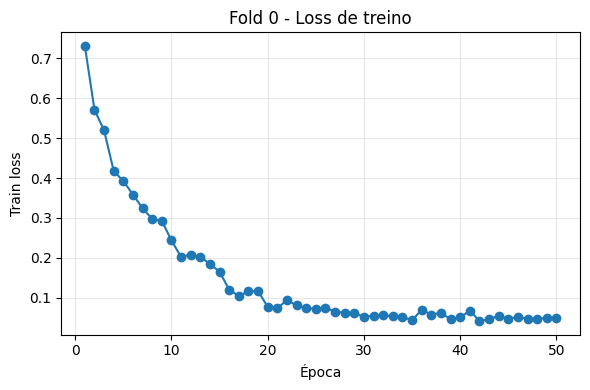

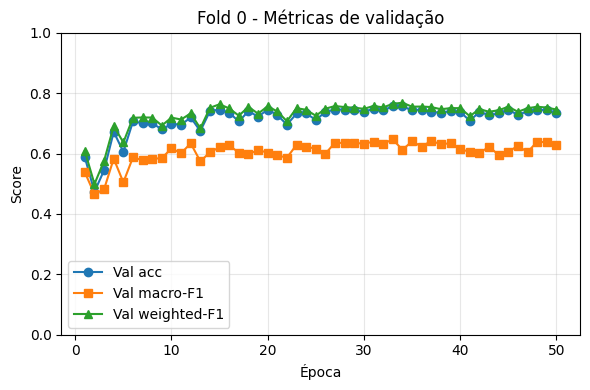


Fold 1


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,1,1,0.747830,0.689796,0.583465,0.697681,0.0001,248.484159
1,1,2,0.602737,0.702041,0.634345,0.711093,0.0001,245.464547
2,1,3,0.538289,0.767347,0.671067,0.780696,0.0001,245.576065
3,1,4,0.476373,0.793878,0.719965,0.796922,0.0001,245.696098
4,1,5,0.434198,0.771429,0.701500,0.778712,0.0001,245.852578


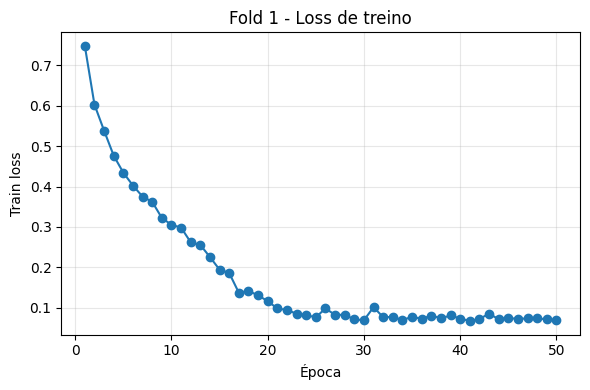

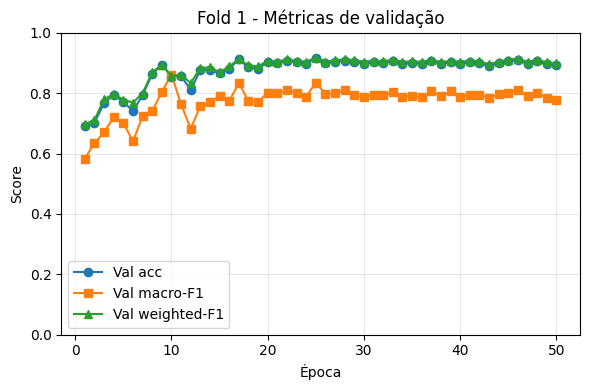


Fold 2


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,2,1,0.772768,0.811224,0.660535,0.807010,0.0001,267.287679
1,2,2,0.618865,0.835034,0.717104,0.839255,0.0001,265.280970
2,2,3,0.563362,0.824830,0.706279,0.826121,0.0001,264.736782
3,2,4,0.488576,0.835034,0.764974,0.841336,0.0001,265.536420
4,2,5,0.483122,0.874150,0.795193,0.876501,0.0001,265.157782


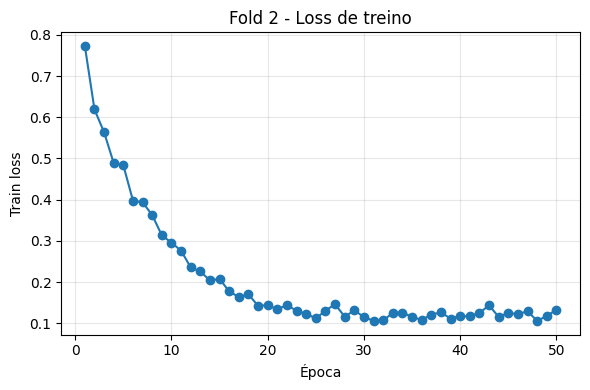

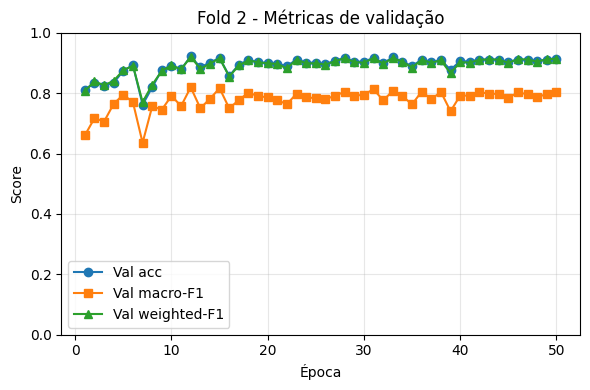


Fold 3


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,3,1,0.846721,0.836043,0.797861,0.836590,0.0001,391.235943
1,3,2,0.703116,0.887534,0.857663,0.887285,0.0001,310.733490
2,3,3,0.636473,0.856369,0.766597,0.859813,0.0001,306.739954
3,3,4,0.536176,0.891599,0.814314,0.886963,0.0001,481.577758
4,3,5,0.510990,0.888889,0.829276,0.888104,0.0001,323.084983


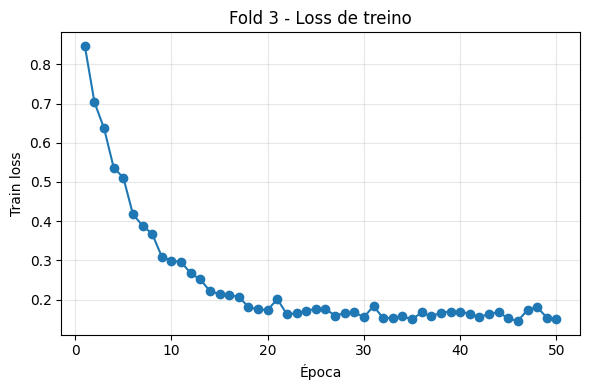

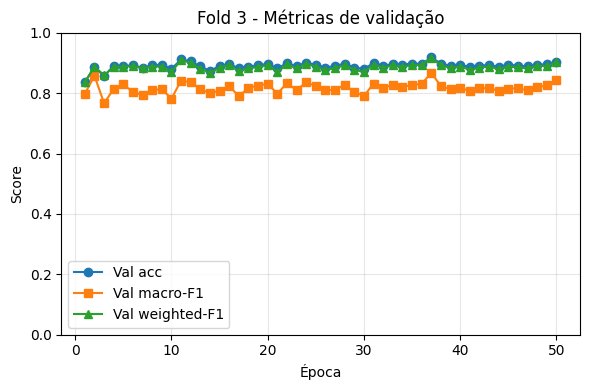


Fold 4


,fold,epoch,train_loss,val_acc,val_macro_f1,val_weighted_f1,lr,epoch_time_sec
0,4,1,0.816102,0.765472,0.480111,0.766077,0.0001,842.823623
1,4,2,0.643423,0.820847,0.537600,0.780228,0.0001,846.373642
2,4,3,0.579111,0.811075,0.529888,0.801358,0.0001,843.760804
3,4,4,0.536400,0.825733,0.487097,0.800126,0.0001,844.662570
4,4,5,0.471470,0.631922,0.326334,0.668857,0.0001,849.015642


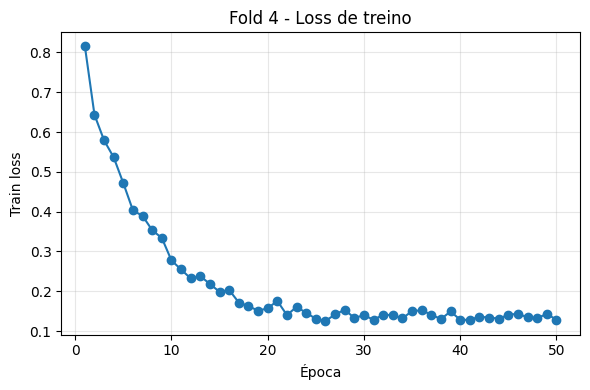

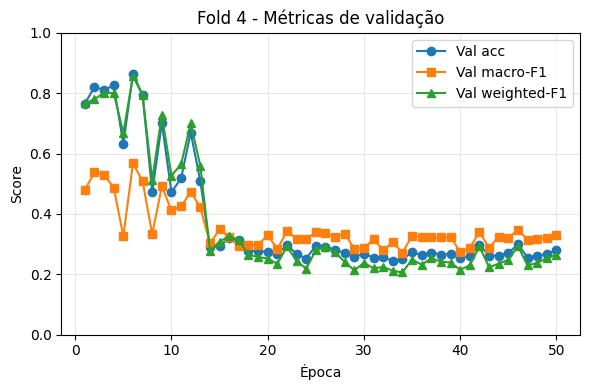

In [3]:
# =========================================================
# GRÁFICOS DE TREINO POR FOLD
# =========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\merged_4classes\slowfast_runs_4cls_5fold")

for fold in range(5):
    hist_path = RUNS_ROOT / f"fold{fold}" / "history.csv"
    if not hist_path.exists():
        print(f"[AVISO] Não encontrado: {hist_path}")
        continue

    df = pd.read_csv(hist_path)

    print(f"\nFold {fold}")
    display(df.head())

    # Loss de treino
    plt.figure(figsize=(6, 4))
    plt.plot(df["epoch"], df["train_loss"], marker="o")
    plt.title(f"Fold {fold} - Loss de treino")
    plt.xlabel("Época")
    plt.ylabel("Train loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Métricas de validação
    plt.figure(figsize=(6, 4))
    plt.plot(df["epoch"], df["val_acc"], marker="o", label="Val acc")
    plt.plot(df["epoch"], df["val_macro_f1"], marker="s", label="Val macro-F1")
    plt.plot(df["epoch"], df["val_weighted_f1"], marker="^", label="Val weighted-F1")
    plt.title(f"Fold {fold} - Métricas de validação")
    plt.xlabel("Época")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Six-class SlowFast experiment with 50 epochs

This section introduces the extended six-class SlowFast experiment. The purpose is to train the six-class RGB baseline with a longer schedule and compare it with the shorter six-class run and with skeleton-based models.


## Train the six-class SlowFast model with the longer schedule

This cell runs the full five-fold SlowFast training procedure for the six-class setting using a longer training configuration. It defines the dataset, data loaders, model architecture, optimization loop, validation procedure, and artifact export logic for each fold.


In [5]:
# =========================================================
# SLOWFAST 6 CLASSES — DATASET + TREINO 5 FOLDS (50 ÉPOCAS)
# =========================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from pytorchvideo.models.hub import slowfast_r50

# =========================================================
# DATASET
# =========================================================

class PigSlowFastDataset(Dataset):
    def __init__(self, csv_path, src_frames=15, fast_frames=32, slow_frames=8, img_size=224):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.src_frames = src_frames
        self.fast_frames = fast_frames
        self.slow_frames = slow_frames
        self.img_size = img_size

        self.fast_idx = np.linspace(0, self.src_frames - 1, self.fast_frames).round().astype(int)
        self.slow_idx = np.linspace(0, self.fast_frames - 1, self.slow_frames).round().astype(int)

    def __len__(self):
        return len(self.df)

    def _load_src_clip(self, clip_dir):
        frames = []
        clip_dir = Path(clip_dir)

        for t in range(self.src_frames):
            p = clip_dir / f"img_{t:03d}.jpg"
            img = cv2.imread(str(p))
            if img is None:
                raise ValueError(f"Erro ao ler: {p}")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype(np.float32) / 255.0

            mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
            std = np.array([0.225, 0.225, 0.225], dtype=np.float32)
            img = (img - mean) / std

            img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
            frames.append(img)

        return np.stack(frames, axis=0)  # (T, C, H, W)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_clip = self._load_src_clip(row["clip_dir"])   # (15, C, H, W)

        fast = src_clip[self.fast_idx]                    # (32, C, H, W)
        fast = np.transpose(fast, (1, 0, 2, 3))          # (C, 32, H, W)
        slow = fast[:, self.slow_idx, :, :]              # (C, 8, H, W)

        slow = torch.tensor(slow, dtype=torch.float32)
        fast = torch.tensor(fast, dtype=torch.float32)
        y = int(row["label_idx"])

        meta = {
            "clip_name": row["clip_name"],
            "clip_idx": int(row["clip_idx"]),
            "track_id": int(row["track_id"]),
            "start_frame": int(row["start_frame"]),
            "label_name": row["label_name"],
        }
        return [slow, fast], y, meta

def collate_fn(batch):
    slow = torch.stack([b[0][0] for b in batch], dim=0)
    fast = torch.stack([b[0][1] for b in batch], dim=0)
    y = torch.tensor([b[1] for b in batch], dtype=torch.long)
    meta = [b[2] for b in batch]
    return [slow, fast], y, meta

print("✅ Dataset carregado")

# =========================================================
# CONFIG
# =========================================================

ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml")
FOLDS_DIR = ROOT / "folds_aligned"
SAVE_ROOT = ROOT / "slowfast_runs_5fold_50epochs"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

LABELS_MAP = Path(r"F:\meus_dados_degcn_5300f_T15\labels_mix_map.json")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4          # mais seguro para RTX 3070
NUM_WORKERS = 0         # Windows
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 224
SRC_FRAMES = 15
FAST_FRAMES = 32
SLOW_FRAMES = 8

print("DEVICE:", DEVICE)

# =========================================================
# CLASSES
# =========================================================

with open(LABELS_MAP, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
elif "class_to_idx" in mp:
    idx_to_class = {int(v): k for k, v in mp["class_to_idx"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

with open(SAVE_ROOT / "class_names.json", "w", encoding="utf-8") as f:
    json.dump({"idx_to_class": {str(i): c for i, c in enumerate(class_names)}}, f, ensure_ascii=False, indent=2)

# =========================================================
# LOOP 5 FOLDS
# =========================================================

global_summary = []

for fold in range(5):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    csv_train = FOLDS_DIR / f"fold{fold}_train.csv"
    csv_val   = FOLDS_DIR / f"fold{fold}_val.csv"

    if not csv_train.exists() or not csv_val.exists():
        raise FileNotFoundError(f"CSV do fold {fold} não encontrado.")

    ds_train = PigSlowFastDataset(csv_train, SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)
    ds_val   = PigSlowFastDataset(csv_val,   SRC_FRAMES, FAST_FRAMES, SLOW_FRAMES, IMG_SIZE)

    dl_train = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_fn
    )
    dl_val = DataLoader(
        ds_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_fn
    )

    print("Train:", len(ds_train))
    print("Val  :", len(ds_val))

    df_train = pd.read_csv(csv_train)
    counts = df_train["label_idx"].value_counts().sort_index()

    weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for c in range(NUM_CLASSES):
        n = counts.get(c, 1)
        weights[c] = len(df_train) / (NUM_CLASSES * n)

    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print("Class weights:", weights)

    model = slowfast_r50(pretrained=False)
    in_features = model.blocks[-1].proj.in_features
    model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_macro_f1 = -1.0
    best_epoch = -1
    history = []

    fold_dir = SAVE_ROOT / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n[FOLD {fold}] EPOCH {epoch+1}/{EPOCHS}")

        # ---------------- TRAIN ----------------
        model.train()
        train_losses = []

        for i, (x, y, _) in enumerate(dl_train):
            if i % 50 == 0:
                print(f"[TRAIN] batch {i}/{len(dl_train)}")

            x = [t.to(DEVICE, non_blocking=True) for t in x]
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan

        # ---------------- VAL ----------------
        model.eval()
        y_true = []
        y_pred = []
        probs_all = []
        meta_all = []
        val_losses = []

        with torch.no_grad():
            for i, (x, y, meta_batch) in enumerate(dl_val):
                if i % 50 == 0:
                    print(f"[VAL] batch {i}/{len(dl_val)}")

                x = [t.to(DEVICE, non_blocking=True) for t in x]
                y_gpu = y.to(DEVICE, non_blocking=True)

                logits = model(x)
                loss_val = criterion(logits, y_gpu)
                val_losses.append(loss_val.item())

                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = probs.argmax(axis=1)

                y_true.append(y.numpy())
                y_pred.append(pred)
                probs_all.append(probs)
                meta_all.extend(meta_batch)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        probs_all = np.concatenate(probs_all)

        val_loss = float(np.mean(val_losses)) if len(val_losses) > 0 else np.nan
        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")

        epoch_time = time.time() - t0

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": acc,
            "val_macro_f1": macro_f1,
            "val_weighted_f1": weighted_f1,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[FOLD {fold}] epoch={epoch+1} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"acc={acc:.4f} | "
            f"macro_f1={macro_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        scheduler.step(macro_f1)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1

            print(f"🔥 [FOLD {fold}] Novo melhor modelo na época {best_epoch} (macro-F1={best_macro_f1:.4f})")

            torch.save(model.state_dict(), fold_dir / "best.pt")

            np.savez_compressed(
                fold_dir / "val_artifacts_best.npz",
                y_true=y_true,
                y_pred=y_pred,
                probs=probs_all
            )

            pd.DataFrame(meta_all).to_csv(
                fold_dir / "meta_val_best.csv",
                index=False,
                encoding="utf-8-sig"
            )

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
            pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
                fold_dir / "confusion_matrix_best.csv",
                encoding="utf-8-sig"
            )

            rep = classification_report(
                y_true,
                y_pred,
                labels=np.arange(NUM_CLASSES),
                target_names=class_names,
                output_dict=True,
                zero_division=0
            )
            pd.DataFrame(rep).T.to_csv(
                fold_dir / "classification_report_best.csv",
                encoding="utf-8-sig"
            )

            with open(fold_dir / "summary_best.json", "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "fold": fold,
                        "best_epoch": best_epoch,
                        "best_val_acc": acc,
                        "best_val_macro_f1": macro_f1,
                        "best_val_weighted_f1": weighted_f1,
                        "n_train": len(ds_train),
                        "n_val": len(ds_val),
                        "class_names": class_names,
                    },
                    f,
                    ensure_ascii=False,
                    indent=2
                )

        pd.DataFrame(history).to_csv(
            fold_dir / "history.csv",
            index=False,
            encoding="utf-8-sig"
        )

    global_summary.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    })

global_summary_df = pd.DataFrame(global_summary)
global_summary_df.to_csv(
    SAVE_ROOT / "global_summary_folds.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 70)
print("[OK] TREINAMENTO 5 FOLDS FINALIZADO")
print("=" * 70)
display(global_summary_df)
print("Artefatos salvos em:", SAVE_ROOT)

✅ Dataset carregado
DEVICE: cuda
Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']

FOLD 0
Train: 2430
Val  : 378
Class weights: tensor([1.2898, 1.8326, 0.6995, 2.3824, 0.8508, 0.6045], device='cuda:0')

[FOLD 0] EPOCH 1/50
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608
[TRAIN] batch 500/608
[TRAIN] batch 550/608
[TRAIN] batch 600/608
[VAL] batch 0/95
[VAL] batch 50/95
[FOLD 0] epoch=1 | train_loss=1.2150 | val_loss=1.7450 | acc=0.3571 | macro_f1=0.2886 | weighted_f1=0.2989 | time=600.2s
🔥 [FOLD 0] Novo melhor modelo na época 1 (macro-F1=0.2886)

[FOLD 0] EPOCH 2/50
[TRAIN] batch 0/608
[TRAIN] batch 50/608
[TRAIN] batch 100/608
[TRAIN] batch 150/608
[TRAIN] batch 200/608
[TRAIN] batch 250/608
[TRAIN] batch 300/608
[TRAIN] batch 350/608
[TRAIN] batch 400/608
[TRAIN] batch 450/608
[TRAIN] b

,fold,best_epoch,best_macro_f1,n_train,n_val
0,0,50,0.554858,2430,378
1,1,4,0.581678,2318,490
2,2,29,0.748826,2220,588
3,3,37,0.700516,2070,738
4,4,7,0.394792,2194,614


Artefatos salvos em: F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold_50epochs


## Consolidate final metrics for the extended six-class SlowFast experiment

This cell aggregates predictions and probabilities from the extended six-class SlowFast runs. It computes global classification metrics, average precision, confusion matrices, and saves consolidated outputs for reporting and comparison with other representations.


Classes: ['walking', 'running', 'eating', 'drinking', 'lying awake', 'sleeping']
Fold 0: n=378 | acc=0.4762 | macro_f1=0.3294
Fold 1: n=490 | acc=0.5633 | macro_f1=0.5206
Fold 2: n=588 | acc=0.6973 | macro_f1=0.6351
Fold 3: n=738 | acc=0.7791 | macro_f1=0.5796
Fold 4: n=614 | acc=0.4609 | macro_f1=0.3550

Total consolidado:
y_true_all: (2808,)
y_pred_all: (2808,)
probs_all : (2808, 6)

Resumo global:
Accuracy   : 0.613960
Macro-F1   : 0.517727
Weighted-F1: 0.568816

Resultado por classe:


,precision,recall,f1-score,support
walking,0.500780,0.812658,0.619691,395.00000
running,1.000000,0.004484,0.008929,223.00000
eating,0.694259,0.797546,0.742327,652.00000
drinking,0.625571,0.778409,0.693671,176.00000
lying awake,0.543396,0.246154,0.338824,585.00000
sleeping,0.644159,0.773488,0.702924,777.00000
accuracy,0.613960,0.613960,0.613960,0.61396
macro avg,0.668027,0.568790,0.517727,2808.00000
weighted avg,0.641725,0.613960,0.568816,2808.00000



Matriz de confusão consolidada:


,walking,running,eating,drinking,lying awake,sleeping
walking,321,0,34,10,25,5
running,222,1,0,0,0,0
eating,36,0,520,2,22,72
drinking,3,0,1,137,24,11
lying awake,57,0,100,40,144,244
sleeping,2,0,94,30,50,601



Matriz de confusão normalizada:


...

,class_idx,class_name,AP
0,0,walking,0.439837
1,1,running,0.059920
2,2,eating,0.834779
3,3,drinking,0.768029
4,4,lying awake,0.435529
5,5,sleeping,0.760826



mAP consolidado: 0.549820

Resumo por fold:


,fold,n_samples,accuracy,macro_f1,weighted_f1
0,0,378,0.476190,0.329396,0.474235
1,1,490,0.563265,0.520571,0.503250
2,2,588,0.697279,0.635103,0.674320
3,3,738,0.779133,0.579644,0.766563
4,4,614,0.460912,0.354971,0.330560



Resumo global:


,accuracy,macro_f1,weighted_f1,mAP,AP_walking,AP_running,AP_eating,AP_drinking,AP_lying awake,AP_sleeping
0,0.61396,0.517727,0.568816,0.54982,0.439837,0.05992,0.834779,0.768029,0.435529,0.760826


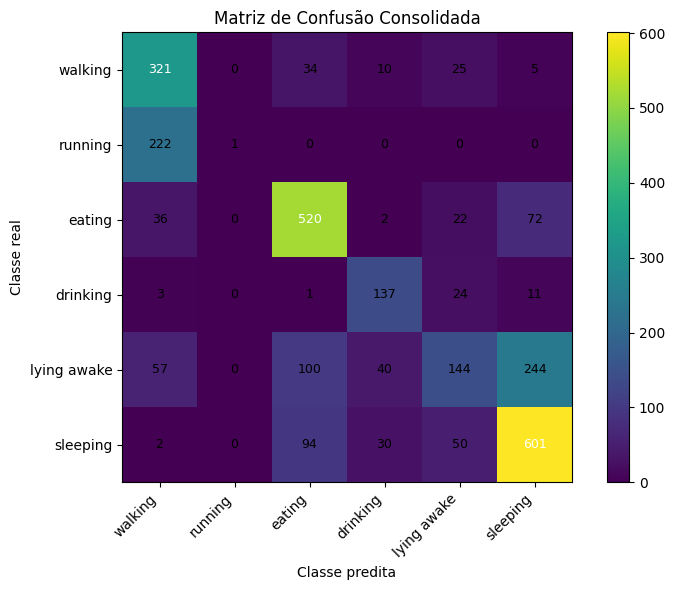

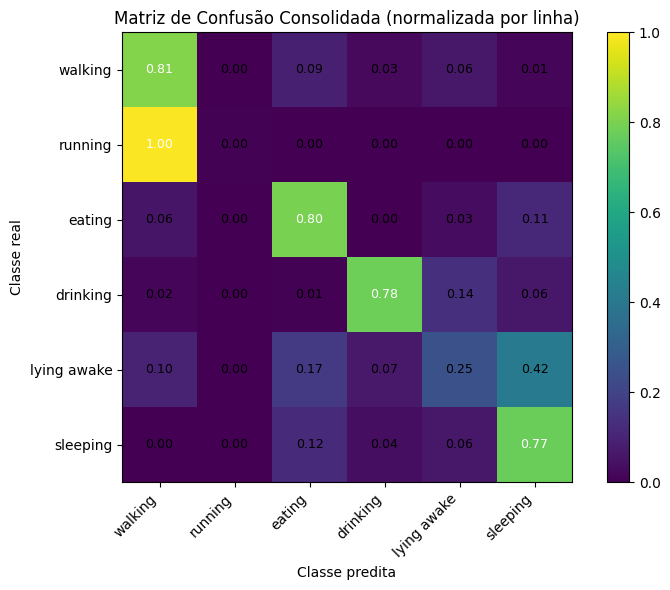


Arquivos salvos em:
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\classification_report_consolidated.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated_row_normalized.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\average_precision_per_class.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\fold_summary.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\global_summary.csv
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated.png
 - F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold\consolidated_metrics\confusion_matrix_consolidated_row_normalized.png


In [7]:
# =========================================================
# MATRIZ DE CONFUSÃO CONSOLIDADA + MÉTRICAS DE DESEMPENHO
# SlowFast - 5 folds
# =========================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

RUNS_ROOT = Path(r"F:\slowfast_dataset_degcn_aligned_5300xml\slowfast_runs_5fold")
CLASS_JSON = RUNS_ROOT / "class_names.json"
OUTDIR = RUNS_ROOT / "consolidated_metrics"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# LOAD CLASS NAMES
# ---------------------------------------------------------

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    mp = json.load(f)

if "idx_to_class" in mp:
    idx_to_class = {int(k): v for k, v in mp["idx_to_class"].items()}
else:
    idx_to_class = {int(k): v for k, v in mp.items()}

class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
n_classes = len(class_names)

print("Classes:", class_names)

# ---------------------------------------------------------
# LOAD FOLD ARTIFACTS
# ---------------------------------------------------------

all_y_true = []
all_y_pred = []
all_probs = []
fold_summary = []

for fold in range(5):
    fold_dir = RUNS_ROOT / f"fold{fold}"
    art_path = fold_dir / "val_artifacts_best.npz"

    if not art_path.exists():
        print(f"[AVISO] Arquivo não encontrado: {art_path}")
        continue

    z = np.load(art_path, allow_pickle=True)

    y_true = z["y_true"].astype(int)
    y_pred = z["y_pred"].astype(int)
    probs = z["probs"]

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)
    all_probs.append(probs)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    fold_summary.append({
        "fold": fold,
        "n_samples": len(y_true),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    })

    print(f"Fold {fold}: n={len(y_true)} | acc={acc:.4f} | macro_f1={macro_f1:.4f}")

if len(all_y_true) == 0:
    raise RuntimeError("Nenhum val_artifacts_best.npz foi encontrado.")

# ---------------------------------------------------------
# CONSOLIDATE
# ---------------------------------------------------------

y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
probs_all = np.concatenate(all_probs)

print("\nTotal consolidado:")
print("y_true_all:", y_true_all.shape)
print("y_pred_all:", y_pred_all.shape)
print("probs_all :", probs_all.shape)

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------

acc_all = accuracy_score(y_true_all, y_pred_all)
macro_f1_all = f1_score(y_true_all, y_pred_all, average="macro")
weighted_f1_all = f1_score(y_true_all, y_pred_all, average="weighted")

print("\nResumo global:")
print(f"Accuracy   : {acc_all:.6f}")
print(f"Macro-F1   : {macro_f1_all:.6f}")
print(f"Weighted-F1: {weighted_f1_all:.6f}")

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

report = classification_report(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_csv = OUTDIR / "classification_report_consolidated.csv"
report_df.to_csv(report_csv, encoding="utf-8-sig")

print("\nResultado por classe:")
display(report_df)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes)
)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv = OUTDIR / "confusion_matrix_consolidated.csv"
cm_df.to_csv(cm_csv, encoding="utf-8-sig")

# normalizada por linha
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
cm_norm_csv = OUTDIR / "confusion_matrix_consolidated_row_normalized.csv"
cm_norm_df.to_csv(cm_norm_csv, encoding="utf-8-sig")

print("\nMatriz de confusão consolidada:")
display(cm_df)

print("\nMatriz de confusão normalizada:")
display(cm_norm_df)

# ---------------------------------------------------------
# AP POR CLASSE + mAP
# ---------------------------------------------------------

Y_bin = label_binarize(y_true_all, classes=np.arange(n_classes))

ap_rows = []
aps = []

for c in range(n_classes):
    if Y_bin[:, c].sum() == 0:
        ap = np.nan
    else:
        ap = average_precision_score(Y_bin[:, c], probs_all[:, c])

    aps.append(ap)
    ap_rows.append({
        "class_idx": c,
        "class_name": class_names[c],
        "AP": ap
    })

ap_df = pd.DataFrame(ap_rows)
map_value = np.nanmean(aps)

ap_csv = OUTDIR / "average_precision_per_class.csv"
ap_df.to_csv(ap_csv, index=False, encoding="utf-8-sig")

print("\nAP por classe:")
display(ap_df)

print(f"\nmAP consolidado: {map_value:.6f}")

# ---------------------------------------------------------
# FOLD SUMMARY
# ---------------------------------------------------------

fold_summary_df = pd.DataFrame(fold_summary)
fold_summary_csv = OUTDIR / "fold_summary.csv"
fold_summary_df.to_csv(fold_summary_csv, index=False, encoding="utf-8-sig")

print("\nResumo por fold:")
display(fold_summary_df)

# ---------------------------------------------------------
# GLOBAL SUMMARY
# ---------------------------------------------------------

global_summary = pd.DataFrame([{
    "accuracy": acc_all,
    "macro_f1": macro_f1_all,
    "weighted_f1": weighted_f1_all,
    "mAP": map_value,
    **{f"AP_{row['class_name']}": row["AP"] for _, row in ap_df.iterrows()}
}])

global_summary_csv = OUTDIR / "global_summary.csv"
global_summary.to_csv(global_summary_csv, index=False, encoding="utf-8-sig")

print("\nResumo global:")
display(global_summary)

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------

ticks = np.arange(n_classes)

# matriz absoluta
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão Consolidada")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

thresh = cm.max() / 2 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=9
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
png_abs = OUTDIR / "confusion_matrix_consolidated.png"
plt.savefig(png_abs, dpi=200, bbox_inches="tight")
plt.show()

# matriz normalizada
plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
plt.title("Matriz de Confusão Consolidada (normalizada por linha)")
plt.colorbar()
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black",
            fontsize=9
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
png_norm = OUTDIR / "confusion_matrix_consolidated_row_normalized.png"
plt.savefig(png_norm, dpi=200, bbox_inches="tight")
plt.show()

print("\nArquivos salvos em:")
print(" -", report_csv)
print(" -", cm_csv)
print(" -", cm_norm_csv)
print(" -", ap_csv)
print(" -", fold_summary_csv)
print(" -", global_summary_csv)
print(" -", png_abs)
print(" -", png_norm)

## Empty cell

This cell is empty in the original notebook and is retained only to preserve the notebook structure.


## Empty cell

This cell is empty in the original notebook and is retained only to preserve the notebook structure.
